# **Youtube Video Views Prediction**

## 📌 Problem Statement  

A digital media analytics company in India aims to forecast YouTube video performance to support content creators and marketers in optimizing their content strategies. However, the current approach lacks predictive capabilities, making it challenging to estimate the potential success of a video before publishing. This results in missed opportunities for maximizing audience engagement and leveraging trends effectively.  

## 📌 Goals  

- Predict YouTube video performance: Develop a machine learning model to forecast the number of views a video might generate before it is uploaded. (**MAIN**)  
- Assist content creators and marketers: Enable data-driven decisions in content planning and optimization. (**SECONDARY**)  

## 📌 Objectives  

The project seeks to achieve the following objectives:  

1. Build a predictive model capable of estimating the number of views a video will generate, leveraging historical data and video metadata.  
2. Identify key features influencing viewership trends to provide actionable insights for video optimization.  
3. Help creators and marketers align their strategies with emerging trends and maximize audience reach.  

## 📌 Business Metrics  

- **Mean Absolute Percentage Error (R2):** Measure the accuracy of the predicted view count compared to the actual view count. (**MAIN**)  
- **Engagement Rate (ER):** Percentage of interactions (likes, comments, shares) relative to the video views to gauge engagement potential. (**SECONDARY**)  

# **STAGE 1 : EXPLORATORY DATA ANALYSIS (EDA)**

## Project Setup

In [1]:
import os
from pathlib import Path

# Change working directory (for I/O operations)
os.chdir(Path.cwd())

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Settings
sns.set_style('darkgrid')
pd.set_option('display.max_columns', None)

### Specific for Google Colab

In [ ]:
# # Check if running in Google Colab
# import sys
# IN_COLAB = 'google.colab' in sys.modules

# if IN_COLAB:
#     # Install uv package manager
#     !pip install uv

#     # Install dependencies
#     !uv pip install pandas numpy matplotlib seaborn scipy scikit-learn xgboost category-encoders joblib ipykernel gradio openpyxl deep-translator tenacity tqdm langid

#     # # Mount Google Drive (if data is stored there)
#     # from google.colab import drive
#     # drive.mount('/content/drive')

#     # Option 1: Load from Google Drive
#     # df_raw = pd.read_excel('/content/drive/MyDrive/path/to/youtube_statistics.xlsx')

#     # Option 2: Upload file directly
#     from google.colab import files
#     uploaded = files.upload()  # This will prompt you to upload the file

#     # Import libraries
#     import pandas as pd
#     import numpy as np
#     import matplotlib.pyplot as plt
#     import seaborn as sns

#     import warnings
#     warnings.filterwarnings('ignore')

#     # Settings
#     sns.set_style('darkgrid')
#     pd.set_option('display.max_columns', None)

#     df_raw = pd.read_excel('youtube_statistics.xlsx')

#     # Option 3: Load from URL (if hosted online)
#     # df_raw = pd.read_excel('https://your-url.com/youtube_statistics.xlsx')

#     # Create a copy of the dataframe
#     df = df_raw.copy()
#     display(df)

## Data Understanding & Initial Transformation

In [ ]:
# Read data
df_raw = pd.read_excel('data/youtube_statistics.xlsx')

# Create a copy of the dataframe
df = df_raw.copy()
display(df)

,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed,description,No_tags,desc_len,len_title,publish_date
0,2017-11-14,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,12:20:39,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,False,False,False,Presenting Sharry Mann latest Punjabi Song Cu...,15,920,81,2017-11-12
1,2017-11-14,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,05:43:56,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101,735,904,0,True,False,False,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",19,2232,58,2017-11-13
2,2017-11-14,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,15:48:08,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,False,False,False,Watch Stylish Star Allu Arjun @ ChaySam Weddin...,14,482,58,2017-11-12
3,2017-11-14,Eruma Saani | Tamil vs English,Eruma Saani,23,07:08:48,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,False,False,False,This video showcases the difference between pe...,20,263,30,2017-11-12
4,2017-11-14,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,01:14:16,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,False,False,False,why Samantha became EMOTIONAL @ Samantha naga ...,11,753,88,2017-11-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36786,2018-06-14,फेकू आशिक़ - राजस्थान की सबसे शानदार कॉमेडी | ...,RDC Rajasthani,23,08:01:11,"twinkle vaishnav comedy|""twinkle vaishnav""|""tw...",214378,3291,404,196,False,False,False,PRG Music & RDC Rajasthani presents फेकू आशिक़...,19,818,100,2018-06-13
36787,2018-06-14,Seetha | Flowers | Ep# 364,Flowers TV,24,11:30:04,"flowers serials|""actress""|""malayalam serials""|...",406828,1726,478,1428,False,False,False,"Flowers - A R Rahman Show,Book your Tickets He...",8,468,26,2018-06-13
36788,2018-06-14,Bhramanam I Episode 87 - 12 June 2018 I Mazhav...,Mazhavil Manorama,24,05:00:02,"mazhavil manorama|""bhramanam full episode""|""gt...",386319,1216,453,697,False,False,False,Subscribe to Mazhavil Manorama now for your da...,8,2187,57,2018-06-13
36789,2018-06-14,Nua Bohu | Full Ep 285 | 13th June 2018 | Odia...,Tarang TV,24,15:07:49,"tarang|""tarang tv""|""tarang tv online""|""tarang ...",130263,698,115,65,False,False,False,Nuabohu : Story of a rustic village girl who w...,15,432,64,2018-06-13


In [5]:
# Check data information using utility function
from utils import check_data_information

info_df = check_data_information(df, df.columns.tolist())
display(info_df)

,Feature,Data Type,Null Values,Null Percentage,Zero Values,Zero Percentage,Negative Values,Negative Percentage,Empty Strings,Numeric in Object,Duplicated Values,Unique Values,Cardinality Ratio,Unique Sample
0,trending_date,object,0,0.00,0,0.00,0,0.0,0,0,4229,205,0.0056,"2017-11-14, 2017-11-15, 2017-11-16, 2017-11-17..."
1,title,object,0,0.00,0,0.00,0,0.0,0,0,4229,16431,0.4466,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...
2,channel_title,object,0,0.00,0,0.00,0,0.0,0,0,4229,1390,0.0378,"Lokdhun Punjabi, HJ NEWS, TFPC, Eruma Saani, F..."
3,category_id,int64,0,0.00,0,0.00,0,0.0,0,0,4229,17,0.0005,"1, 25, 24, 23, 10"
4,publish_time,object,0,0.00,0,0.00,0,0.0,0,0,4229,12375,0.3364,"12:20:39, 05:43:56, 15:48:08, 07:08:48, 01:14:16"
5,tags,object,0,0.00,0,0.00,0,0.0,0,0,4229,12463,0.3388,"sharry mann|""sharry mann new song""|""sharry man..."
6,views,int64,0,0.00,0,0.00,0,0.0,0,0,4229,31638,0.8599,"1096327, 590101, 473988, 1242680, 464015"
7,likes,int64,0,0.00,757,2.06,0,0.0,0,0,4229,15473,0.4206,"33966, 735, 2011, 70353, 492"
8,dislikes,int64,0,0.00,766,2.08,0,0.0,0,0,4229,5072,0.1379,"798, 904, 243, 1624, 293"
9,comment_count,int64,0,0.00,1294,3.52,0,0.0,0,0,4229,6024,0.1637,"882, 0, 149, 2684, 66"


In [6]:
# Checking shape of dataframe
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns {df.shape[1]}')

Number of rows: 36791
Number of columns 18


**Quick Overview:**
- Dataset contains 36791 rows, 18 features.
- There are several columns that will be dropped for our analysis.
- Dataset consists of 4 data types; float64, int64, datetime, and object. With several columns that currently has object type need to be transformed into datetime columns (more on this below).
- Dataset contains null values only in `description` column with really small percentage. But in this case the null values in `description` column just means that the videos doesn't have a description so we don't have to drop them.

**Feature Information**

| **Feature Name** | **Description** | **Data Type** | **Specific Data Type** |
|-----------------|-----------------|---------------|----------------------|
| `trending_date` | Date when the video is trending | Date | Timestamp |
| `title` | Video title | Text | String |
| `channel_title` | Channel name | Text | String |
| `category_id` | Video category in label encoding | Numerical | Integer (Categorical) |
| `publish_time` | Video publishing time | Time | Timestamp |
| `tags` | Tags used in the video | Text | String (Array) |
| `views` | Number of video views **(Target Variable)** | Numerical | Integer (Discrete) |
| `likes` | Number of video likes | Numerical | Integer (Discrete) |
| `dislikes` | Number of video dislikes | Numerical | Integer (Discrete) |
| `comment_count` | Number of comments on the video | Numerical | Integer (Discrete) |
| `comments_disabled` | Indicates whether comments are disabled for the video | Boolean | Binary |
| `ratings_disabled` | Indicates whether ratings are disabled for the video | Boolean | Binary |
| `video_error_or_removed` | Indicates whether the video is currently in error or has been removed | Boolean | Binary |
| `description` | Video description | Text | String |
| `No_tags` | Number of tags used | Numerical | Integer (Discrete) |
| `desc_len` | Length of the video description in terms of words | Numerical | Integer (Discrete) |
| `len_title` | Length of the video title in terms of words | Numerical | Integer (Discrete) |
| `publish_date` | Date when the video was published | Date | Timestamp |

In [7]:
# Grouping columns based on their types
nums_cols = ['likes', 'dislikes', 'comment_count', 'No_tags', 'desc_len', 'len_title', 'views']
cats_cols = ['title', 'channel_title', 'tags','description', 'category_id', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed']
dates_cols = ['trending_date', 'publish_time_fixed']

---
Just from these information, there are some useful insight to this data that understanding it could make it easier for further analysis and feature transformation, they are :

- The publish time information is currently separated here into 2 different columns, `publish_date` which already have the correct data type and `publish_time` that currently have object data type. We probably need to and then combine these 2 into 1 as a complete datetime format. Also, to get better insight we need to calculate the date difference between the new combined publish time and the `trending_date` (we can only do this in date since the `trending_date` granuality is limited to days).

- Video category (`category_id`) is displayed as a labelled number already, so we are quite unsure what the details of each video like which one is Gaming, Music Videos, News and Politics, etc.

- `title`, `tags`, and `description` are quite interesting to play around in text mining though it will be quite challenging in separating the english and indian texts (especially since I'm don't even know a single Indian word). So there's a high chance we will only be playing with the lenght of those text columns.

- As for boolean feature like `comments_disabled`, `ratings_disabled`, `video_error_or_removed` potentially could be encoded by one-hot encoding since they are nominal values.

- `channel_title` most likely if we want to use it, will be done through frequency/count encoding similar to other long text features.

- Feature `views` is the target variable, we would later move it to the last order in dataframe (personal preference).
---

Lastly, and probably the most important one is that in here we need to the context and flow of this problem. Since we get these features information after the videos are uploaded, so some features that is outside of our own initial control can't actually be used. For example `comments_count`, `video_error_or_removed`, etc. But this will be done later at feature selection section.

## Initial Transformation

In [8]:
# Re-arrange column (target 'views' at the end --> personal preference)
df = df[[col for col in df.columns if col != 'views'] + ['views']]

In [ ]:
# Combine publish time and publish date columns
df["publish_time_fixed"] = pd.to_datetime(df["publish_date"].astype(str) + " " + df["publish_time"].astype(str))
df.drop(columns=["publish_date", "publish_time"], inplace=True)

# Convert trending_date to datetime format
df['trending_date'] = pd.to_datetime(df['trending_date'])

# Change category id to categorical data type
df['category_id'] = df['category_id'].astype('str')

# Check the values of category_id
df["category_id"].value_counts().sort_values(ascending=False)

# Check the values of category_id with the most values
df.loc[df["category_id"] == "24"].sample(3)

> From that we could make hypothesis that the `category_id` of 24 is probably related to **movies/TV series**. We can try figure out the `category_id` name later using the wordcloud of `title`, `tags`, and `description` for each of them later in the data processing section.

### Translation Section

Since we have mixed language of Indian and English in our text features, we need to be able to solve this before going further into modelling later. There are several options to choose from, one is probably utilize the multilingual model but since this is probably complex, for now we will go with translating the data that contains Indian language into English.

In [1]:
# from utils import run_translation_pipeline

# # With language detection and export
# final_df = run_translation_pipeline(
#     df,
#     columns=['title', 'tags', 'description'],
#     export=True,
#     filename_prefix="youtube_data"
# )

---

# Starting Point 2 (EDA Continuation): After Initial Transformation on Text Columns

In [25]:
# Define data type mappings
dtype_mapping = {
    'category_id': str,
    'comments_disabled': str,
    'ratings_disabled': str,
    'video_error_or_removed': str
}

# Read the translated dataset with specified data types (This is done because CSV files don't preserve data type information)
df = pd.read_csv("data/youtube_data_translated.csv", dtype=dtype_mapping, parse_dates=['trending_date', 'publish_time_fixed'])

# Re-group columns based on their types
nums_cols = ['likes', 'dislikes', 'comment_count', 'No_tags', 'desc_len', 'len_title', 'views']
cats_cols = ['title', 'channel_title', 'tags','description', 'category_id', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed']
dates_cols = ['trending_date', 'publish_time_fixed']

# Re-check the data
display(df.head(1))

# Re-check data information
from utils import check_data_information

info_df = check_data_information(df, df.columns.tolist())
display(info_df)

,trending_date,title,channel_title,category_id,tags,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed,description,No_tags,desc_len,len_title,views,publish_time_fixed
0,2017-11-14,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,"sharry mann|""sharry mann new song""|""sharry man...",33966,798,882,False,False,False,Presenting Sharry Mann latest Punjabi Song Cu...,15,920,81,1096327,2017-11-12 12:20:39


,Feature,Data Type,Null Values,Null Percentage,Zero Values,Zero Percentage,Negative Values,Negative Percentage,Empty Strings,Numeric in Object,Duplicated Values,Unique Values,Cardinality Ratio,Unique Sample
0,trending_date,datetime64[us],0,0.00,0,0.00,0,0.0,0,0,4229,205,0.0056,"2017-11-14 00:00:00, 2017-11-15 00:00:00, 2017..."
1,title,str,0,0.00,0,0.00,0,0.0,0,0,4229,16421,0.4463,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...
2,channel_title,str,0,0.00,0,0.00,0,0.0,0,0,4229,1390,0.0378,"Lokdhun Punjabi, HJ NEWS, TFPC, Eruma Saani, F..."
3,category_id,str,0,0.00,0,0.00,0,0.0,0,36791,4229,17,0.0005,"1, 25, 24, 23, 10"
4,tags,str,0,0.00,0,0.00,0,0.0,0,0,4229,12465,0.3388,"sharry mann|""sharry mann new song""|""sharry man..."
5,likes,int64,0,0.00,757,2.06,0,0.0,0,0,4229,15473,0.4206,"33966, 735, 2011, 70353, 492"
6,dislikes,int64,0,0.00,766,2.08,0,0.0,0,0,4229,5072,0.1379,"798, 904, 243, 1624, 293"
7,comment_count,int64,0,0.00,1294,3.52,0,0.0,0,0,4229,6024,0.1637,"882, 0, 149, 2684, 66"
8,comments_disabled,str,0,0.00,0,0.00,0,0.0,0,0,4229,2,0.0001,"False, True"
9,ratings_disabled,str,0,0.00,0,0.00,0,0.0,0,0,4229,2,0.0001,"False, True"


The new translated version have duplicated values, we will need to handle those first.

In [26]:
# Handle duplicated rows
# Using drop_duplicates() with recommended parameters for clarity and control
df = df.drop_duplicates(keep='first', ignore_index=True)
print(f"Rows after removing duplicates: {len(df)}")

Rows after removing duplicates: 32562


## Univariate Analysis

### Numerical Features

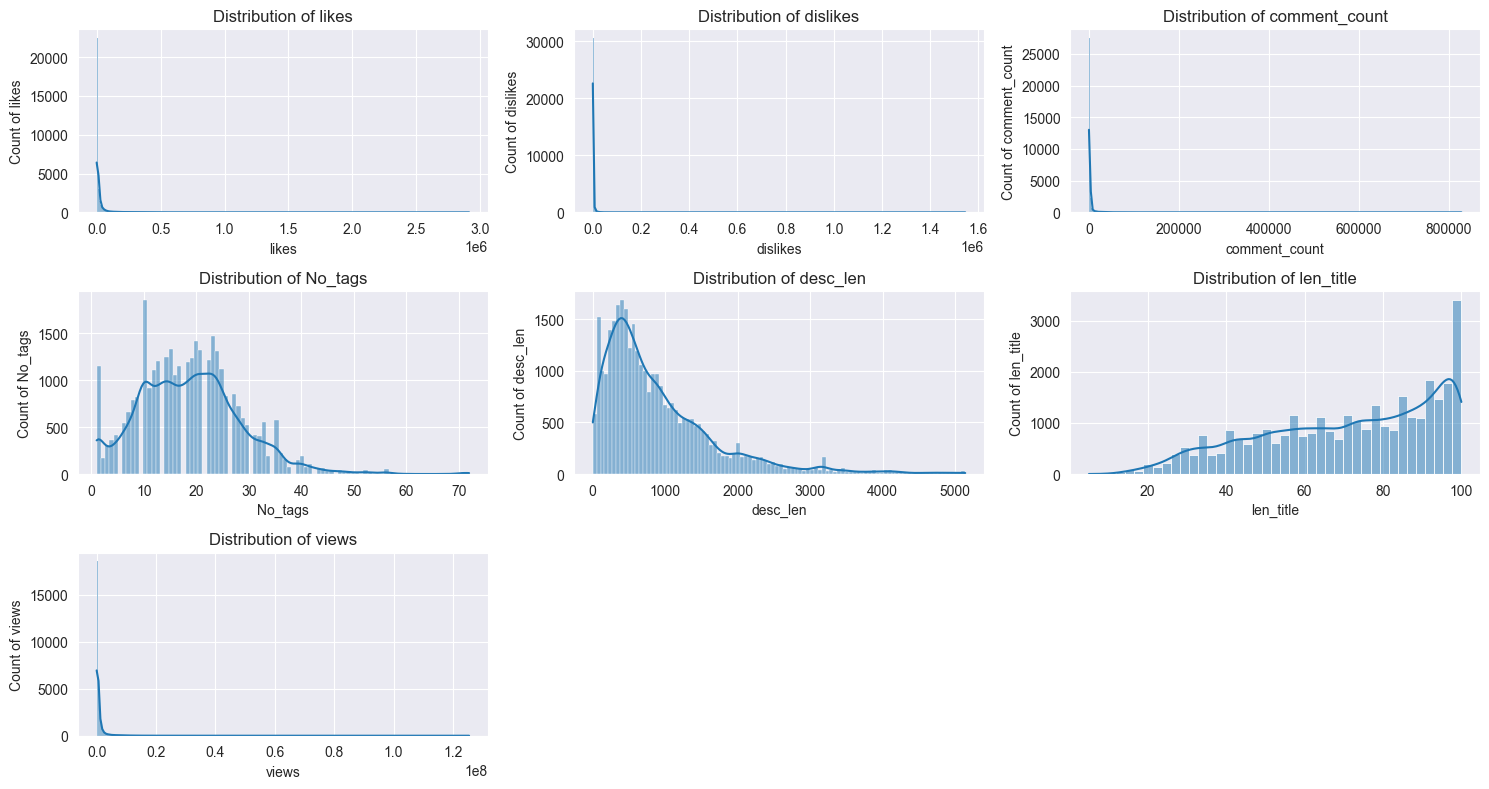

,Feature,overall_count,overall_mean,overall_std,overall_min,overall_25%,overall_50%,overall_75%,overall_max,overall_range,overall_IQR,overall_CV,overall_skewness,overall_kurtosis
0,likes,32562.0,2.595444e+04,9.720113e+04,0.0,800.00,2817.0,12299.0,2912710.0,2912710.0,11499.00,374.506752,11.594982,215.857766
1,dislikes,32562.0,1.596781e+03,1.703103e+04,0.0,99.00,293.0,943.0,1545017.0,1545017.0,844.00,1066.585642,72.091587,5818.454424
2,comment_count,32562.0,2.561673e+03,1.488591e+04,0.0,74.00,306.0,1188.0,827755.0,827755.0,1114.00,581.101041,28.933575,1240.325657
3,No_tags,32562.0,1.884906e+01,9.863164e+00,1.0,12.00,19.0,25.0,72.0,71.0,13.00,52.327093,0.661132,1.347890
4,desc_len,32562.0,9.132707e+02,8.070886e+02,3.0,366.00,673.0,1226.0,5136.0,5133.0,860.00,88.373426,1.879880,4.503816
5,len_title,32562.0,7.099567e+01,2.228042e+01,5.0,54.00,75.0,91.0,100.0,95.0,37.00,31.382792,-0.477445,-0.865722
6,views,32562.0,1.007091e+06,3.171556e+06,4024.0,114162.25,277788.0,738924.5,125432237.0,125428213.0,624762.25,314.922381,12.942517,291.182111


,Column Name,Mean,Median,Mode,Skewness,Kurtosis,Skewness Type,Kurtosis Type
0,likes,25954.441,2817.0,0,11.595,215.858,Highly Positively Skewed,Leptokurtic (Heavy-tailed)
1,dislikes,1596.781,293.0,0,72.092,5818.454,Highly Positively Skewed,Leptokurtic (Heavy-tailed)
2,comment_count,2561.673,306.0,0,28.934,1240.326,Highly Positively Skewed,Leptokurtic (Heavy-tailed)
3,No_tags,18.849,19.0,10,0.661,1.348,Moderately Positively Skewed,Leptokurtic (Heavy-tailed)
4,desc_len,913.271,673.0,295,1.880,4.504,Highly Positively Skewed,Leptokurtic (Heavy-tailed)
5,len_title,70.996,75.0,100,-0.477,-0.866,Slightly Negatively Skewed,Platykurtic (Light-tailed)
6,views,1007091.465,277788.0,1682462,12.943,291.182,Highly Positively Skewed,Leptokurtic (Heavy-tailed)


In [9]:
# Checking the distribution and statistical summary of the numerical values
from utils import plot_dynamic_hisplots_kdeplots, describe_numerical_combined, identify_distribution_types

plot_dynamic_hisplots_kdeplots(df=df, col_series=nums_cols, ncols=3, figsize=(15, 8))

# Display the overall statistics for numerical columns
numerical_summary = describe_numerical_combined(df, nums_cols)
display(numerical_summary)

# Display the distribution types
result = identify_distribution_types(df, df.select_dtypes('number').columns.tolist())
display(result)

### Categorical Features

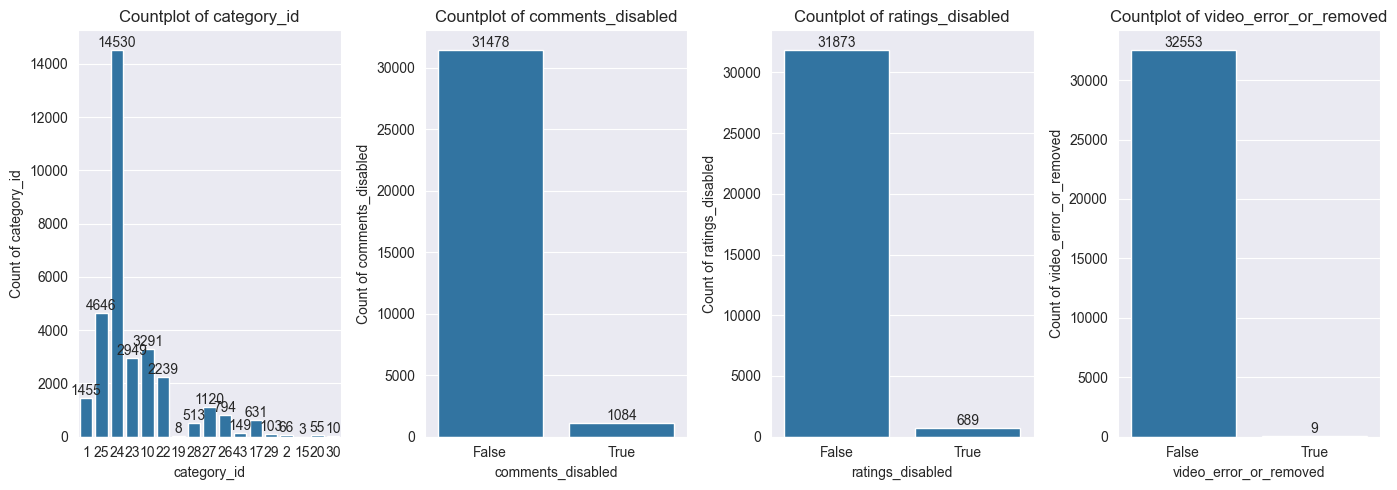

,Feature,overall_count,overall_unique,overall_top,overall_freq,overall_bottom,overall_freq_bottom,overall_top_percentage,overall_bottom_percentage,overall_n_categories
0,title,32562,16421,Nandhini | Today @ 9 pm | Sun TV,15,Daang ( Full Video ) | Mankirt Aulakh | Sukh S...,1,0.05,0.00,16421
1,channel_title,32562,1390,VikatanTV,208,Bollywood Sins,1,0.64,0.00,1390
2,tags,32562,12465,[none],1027,"Resnu desai|""actress renu desai""|""pawan kalyan...",1,3.15,0.00,12465
3,description,32518,13976,Subscribers Link: http://bit.ly/2qb69dZ\n\nCon...,150,Song - Daang\nSinger - Mankirt Aulakh\nFaceboo...,1,0.46,0.00,13976
4,category_id,32562,17,24,14530,15,3,44.62,0.01,17
5,comments_disabled,32562,2,False,31478,True,1084,96.67,3.33,2
6,ratings_disabled,32562,2,False,31873,True,689,97.88,2.12,2
7,video_error_or_removed,32562,2,False,32553,True,9,99.97,0.03,2


In [10]:
# Checking the distribution and statistical summary of categorical values
from utils import describe_categorical_combined, plot_dynamic_countplot

# Define categorical columns with few unique values for visualization
cats_few = ['category_id', 'comments_disabled',
    'ratings_disabled', 'video_error_or_removed']

plot_dynamic_countplot(df=df, col_series=cats_few, ncols=4, figsize=(14, 5))

# Display statistics for categorical columns
categorical_summary = describe_categorical_combined(df, cats_cols)
display(categorical_summary)

There is a significant imbalance in these boolean categorical values, so it will be addressed further, possibly through feature scaling later on if we want to keep them or just drop them altogether especially the `video_error_or_removed` column because of the extreme imbalance here.

### Date Features

In [11]:
from utils import describe_date_columns

# Analyze multiple date columns
describe_date_columns(df, dates_cols)

,count,mean,min,25%,50%,75%,max,date_range_days,date_range_months,date_range_years,unique_years,unique_months,unique_days,weekend_percentage,business_hours_percentage,most_common_month,most_common_weekday,max_gap_days,median_gap_days,future_dates_percentage,is_regular_interval
trending_date,32562,2018-02-19 02:17:53.300165,2017-11-14 00:00:00,2017-12-28 00:00:00,2018-02-14 00:00:00,2018-04-14 00:00:00,2018-06-14 00:00:00,212 days 00:00:00,7.066667,0.580822,2.0,8.0,205.0,29.924452,0.000000,12.0,Saturday,7.0,0.0,0.0,True
publish_time_fixed,32562,2018-02-17 10:41:19.559394,2017-05-27 20:27:30,2017-12-25 18:00:18.250000,2018-02-12 08:44:15,2018-04-12 16:00:27,2018-06-13 18:05:15,381 days 21:37:45,12.700000,1.043836,2.0,9.0,219.0,26.371230,54.483754,12.0,Friday,163.0,0.0,0.0,True


## Bivariate & Multivariate Analysis

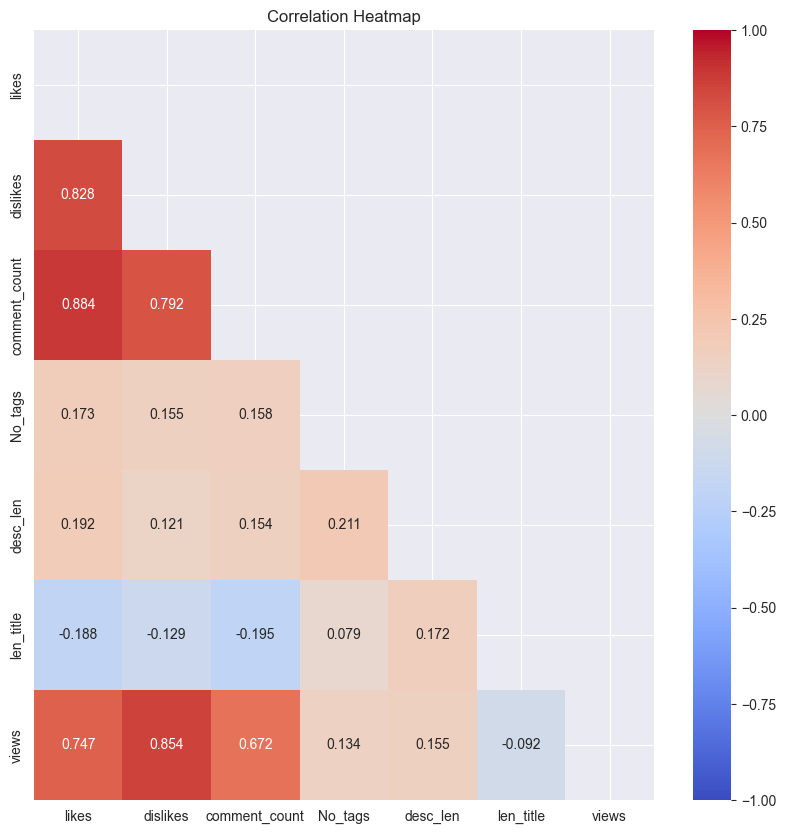

In [12]:
# Create a mask for the upper triangle
plt.figure(figsize=(10,10))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))

# Plot the heatmap
sns.heatmap(data = df.corr(numeric_only=True, method='spearman'), mask=mask, cmap='coolwarm', annot=True, fmt='.3f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

In [14]:
# # Pairplot
# sns.pairplot(df, diag_kind='kde')
# plt.suptitle('Pairplot of Numerical Features')
# plt.tight_layout()
# plt.show()

## Text Columns Analysis

In [27]:
from utils.text_preprocessing import TextPreprocessor, TextVisualizer, quick_clean, get_text_stats

input_file = 'data/youtube_data_translated.csv'
output_file = 'data/youtube_data_text_preprocessed.csv'

# Display sample of raw text data
print("\nSample of raw text data:")
print("-"*40)
sample_cols = ['title', 'description', 'tags']
for col in sample_cols:
    if col in df.columns:
        print(f"\n{col.upper()} (first 3 samples):")
        for i, val in enumerate(df[col].head(3), 1):
            text = str(val)[:100] + "..." if len(str(val)) > 100 else str(val)
            print(f"  {i}. {text}")


Sample of raw text data:
----------------------------------------

TITLE (first 3 samples):
  1. Sharry Mann: Cute Munda ( Song Teaser) | Parmish Verma | Releasing on 17 November
  2. During periods, husband does this on stomach, you will be stunned to see
  3. Stylish Star Allu Arjun @ ChaySam Wedding Reception | TFPC

DESCRIPTION (first 3 samples):
  1. Presenting Sharry Mann latest Punjabi Song  Cute Munda Teaser . The music of new punjabi song is giv...
  2. पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दंग रह जायेंगे \n\nWatch this video :- https://youtu.be/...
  3. Watch Stylish Star Allu Arjun @ ChaySam Wedding Reception \n\n☛ For latest news https://www.tfpc.in,...

TAGS (first 3 samples):
  1. sharry mann|"sharry mann new song"|"sharry mann cute munda"|"sharry mann latest song"|"sharry mann p...
  2. During Periods
  3. Stylish Star Allu Arjun @ ChaySam Wedding Reception|"Stylish Star Allu Arjun"|"ChaySam Wedding Recep...


In [28]:
# Step 2: Calculate text statistics before preprocessing
print("\n" + "-"*80)
print("STEP 2: Text Statistics (Before Preprocessing)")
print("-"*80)
text_stats = get_text_stats(df, ['title', 'description', 'tags'])
print(text_stats.to_string(index=False))


--------------------------------------------------------------------------------
STEP 2: Text Statistics (Before Preprocessing)
--------------------------------------------------------------------------------
     column  total_documents  total_words  avg_words_per_doc  unique_words  avg_word_length
      title            32562       412164              12.66         31166             4.72
description            32518      3468869             106.68        146874             7.43
       tags            32562       852432              26.18        108205            11.22


In [29]:
# Step 3: Initialize TextPreprocessor
print("\n" + "-"*80)
print("STEP 3: Initializing TextPreprocessor")
print("-"*80)
preprocessor = TextPreprocessor(
    language='english',
    custom_stopwords={'youtube', 'video', 'watch', 'channel', 'subscribe'}
)
print(f"Stopwords count: {len(preprocessor._stopwords)}")
print(f"Language: {preprocessor.language}")


--------------------------------------------------------------------------------
STEP 3: Initializing TextPreprocessor
--------------------------------------------------------------------------------
Stopwords count: 203
Language: english


In [30]:
# Step 4: Apply text preprocessing
print("\n" + "-"*80)
print("STEP 4: Applying Text Preprocessing")
print("-"*80)

# Define preprocessing options
preprocessing_options = {
    'replace_newlines': True,
    'remove_html': True,
    'remove_urls': True,
    'remove_emails': True,
    'remove_social': True,  # Remove @mentions and #hashtags
    'expand_contractions': True,
    'remove_accents': True,
    'lowercase': True,
    'remove_special_chars': True,
    'keep_punctuation': False,
    'spell_correction': False,  # Disabled for speed
    'remove_stopwords': True,
    'lemmatize': True,
    'stem': False,  # Use lemmatization, not stemming
    'min_token_length': 2  # Remove single-character tokens
}

print("Preprocessing options:")
for key, value in preprocessing_options.items():
    print(f"  {key}: {value}")

# Apply preprocessing to text columns
text_columns = ['title', 'description', 'tags']
print(f"\nProcessing columns: {text_columns}")
print("This may take a moment for large datasets...")

df_processed = preprocessor.preprocess_dataframe(
    df, 
    columns=text_columns,
    options=preprocessing_options
)

print(f"\n✓ Preprocessing completed for {len(df_processed):,} rows")


--------------------------------------------------------------------------------
STEP 4: Applying Text Preprocessing
--------------------------------------------------------------------------------
Preprocessing options:
  replace_newlines: True
  remove_html: True
  remove_urls: True
  remove_emails: True
  remove_social: True
  expand_contractions: True
  remove_accents: True
  lowercase: True
  remove_special_chars: True
  keep_punctuation: False
  spell_correction: False
  remove_stopwords: True
  lemmatize: True
  stem: False
  min_token_length: 2

Processing columns: ['title', 'description', 'tags']
This may take a moment for large datasets...

✓ Preprocessing completed for 32,562 rows


In [31]:
# Step 5: Show before/after comparison
print("\n" + "-"*80)
print("STEP 5: Before/After Comparison")
print("-"*80)

for col in text_columns[:2]:  # Show first 2 columns
    if col in df.columns:
        print(f"\n{col.upper()}:")
        print("  BEFORE:", str(df[col].iloc[0])[:100] + "...")
        print("  AFTER: ", str(df_processed[col].iloc[0])[:100] + "...")


--------------------------------------------------------------------------------
STEP 5: Before/After Comparison
--------------------------------------------------------------------------------

TITLE:
  BEFORE: Sharry Mann: Cute Munda ( Song Teaser) | Parmish Verma | Releasing on 17 November...
  AFTER:  sharry mann cute munda song teaser parmish verma releasing november...

DESCRIPTION:
  BEFORE: Presenting Sharry Mann latest Punjabi Song  Cute Munda Teaser . The music of new punjabi song is giv...
  AFTER:  presenting sharry mann latest punjabi song cute munda teaser music new punjabi song given gift ruler...


In [32]:
# Step 6: Calculate text statistics after preprocessing
print("\n" + "-"*80)
print("STEP 6: Text Statistics (After Preprocessing)")
print("-"*80)
text_stats_after = get_text_stats(df_processed, text_columns)
print(text_stats_after.to_string(index=False))


--------------------------------------------------------------------------------
STEP 6: Text Statistics (After Preprocessing)
--------------------------------------------------------------------------------
     column  total_documents  total_words  avg_words_per_doc  unique_words  avg_word_length
      title            32562       272296               8.36         16529             5.71
description            32562      2180104              66.95         47520             6.06
       tags            32562       774916              23.80         83509             9.63


In [33]:
# Step 7: Demonstrate quick_clean function
print("\n" + "-"*80)
print("STEP 7: Quick Clean Function Demo")
print("-"*80)

sample_text = "Check out this AMAZING video! http://youtube.com/watch @user #viral"
print(f"Original: {sample_text}")
print(f"Quick clean: {quick_clean(sample_text)}")


--------------------------------------------------------------------------------
STEP 7: Quick Clean Function Demo
--------------------------------------------------------------------------------
Original: Check out this AMAZING video! http://youtube.com/watch @user #viral
Quick clean: check out this amazing video


In [34]:
# Step 8: Create word cloud visualizations (optional)
print("\n" + "-"*80)
print("STEP 8: Word Cloud Visualization")
print("-"*80)

try:
    visualizer = TextVisualizer()
    print("Creating word clouds for preprocessed text...")
    
    # Create word clouds (only for first 1000 rows to save time)
    sample_df = df_processed.head(1000)
    fig = visualizer.create_wordclouds(
        sample_df,
        text_columns=['title', 'tags', 'description'],
        max_words=100,
        colormap='viridis'
    )
    
    # Save the word cloud figure
    wordcloud_path = 'output/wordclouds_preprocessed.png'
    fig.savefig(wordcloud_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"✓ Word clouds saved to: {wordcloud_path}")
    
except Exception as e:
    print(f"Note: Word cloud generation skipped ({e})")


--------------------------------------------------------------------------------
STEP 8: Word Cloud Visualization
--------------------------------------------------------------------------------
Creating word clouds for preprocessed text...
✓ Word clouds saved to: output/wordclouds_preprocessed.png


In [35]:
# Step 9: Export processed DataFrame
print("\n" + "-"*80)
print("STEP 9: Exporting Processed Data")
print("-"*80)

# Keep all original columns plus add processed versions
for col in text_columns:
    if col in df.columns:
        df[f'{col}_original'] = df[col]  # Keep original
        df[col] = df_processed[col]      # Replace with processed

# Save to CSV
df.to_csv(output_file, index=False)
print(f"✓ Exported {len(df):,} rows to: {output_file}")
print(f"  Columns: {len(df.columns)}")
print(f"  File size: {Path(output_file).stat().st_size / 1024:.1f} KB")


--------------------------------------------------------------------------------
STEP 9: Exporting Processed Data
--------------------------------------------------------------------------------
✓ Exported 32,562 rows to: data/youtube_data_text_preprocessed.csv
  Columns: 20
  File size: 70850.4 KB


In [36]:
# Step 10: Summary

print("\n" + "="*80)
print("PROCESSING COMPLETE!")
print("="*80)
print(f"\nInput file:  {input_file}")
print(f"Output file: {output_file}")
print(f"\nProcessed columns:")
for col in text_columns:
    print(f"  - {col}")
print(f"\nTotal rows processed: {len(df):,}")
print("\nThe preprocessed data is ready for modeling!")


PROCESSING COMPLETE!

Input file:  data/youtube_data_translated.csv
Output file: data/youtube_data_text_preprocessed.csv

Processed columns:
  - title
  - description
  - tags

Total rows processed: 32,562

The preprocessed data is ready for modeling!


# **STAGE 2 : DATA PREPROCESSING**

Now we will move on to the actual preprocessing for our modelling. Let's introduce a problem here (24/03/2026): 

> Using likes, dislikes, and comment counts to predict views is data leakage. Those metrics only exist AFTER the video is uploaded and has received engagement. A model trained on them would be useless for predicting views before upload.

Based on Kimi 2.5 suggestions, I have 3 options:

Option 1: Fix the prediction task (Recommended)
Predict views using only pre-upload features:

- Content features: title, description, tags (length, sentiment, keywords)
- Channel features: channel name/category, historical channel performance (avg views of past videos)
- Timing features: publish day/hour/season, is_weekend
- Metadata: video category, description length, tag count
Remove these leakage columns: likes, dislikes, comment_count, *_ratio, trending_duration, trending_day, is_same_day_trending_publish

Option 2: Change the prediction target
Instead of raw views, predict:

- View category (Low/Medium/High) - already in your data
- Trending probability (will it trend within X days?)
- Success tier based on channel size (viral for small channels vs viral for large channels)

Option 3: Two-stage prediction
If you want to use engagement metrics:
1. Stage 1: Predict initial 24-48hr views using pre-upload features only
2. Stage 2: Predict total views using early engagement (likes/comments in first 48hrs)

This is realistic for helping creators optimize videos after upload based on early performance.

My Recommendation:

Go with Option 1 but add channel historical performance (average views of channel's previous videos). This is the strongest predictor of future video success and is available before upload.

`So let's go with option 1.`

In [3]:
# # Run specific preprocessing steps only (once) 
# from utils import run_preprocessing
# df = run_preprocessing()

In [4]:
# Load the preprocessed dataset
df = pd.read_csv('data/youtube_data_preprocessed.csv')

# Check the preprocessed data and its information again
display(df.sample(5))

from utils import check_data_information
info_df = check_data_information(df, df.columns.tolist())
display(info_df)

,channel_title,category_id,category_name,publish_day,publish_month,publish_season,publish_hour_category,title_sentiment_label,description_sentiment_label,tags_sentiment_label,len_title,desc_len,No_tags,has_tags,is_weekend_publish_day,publish_hour,title_sentiment,description_sentiment,tags_sentiment,channel_avg_views,channel_median_views,channel_video_count,channel_historical_avg,views,views_log,views_category
35320,Sonotek Bhakti,10,Music,Monday,June,Summer,Evening,Positive,Positive,Positive,93,374,15,1,0,23,0.452381,0.350000,0.357143,1.816372e+05,114266.0,91,1.852899e+05,150395,11.921027,Low
20057,Thanthi TV,25,News & Politics,Monday,March,Spring,Afternoon,Positive,Positive,Positive,75,1477,27,1,0,16,0.525000,0.178828,0.122222,2.497635e+05,200969.0,105,2.566592e+05,224504,12.321653,Medium
28445,Zee Music Company,10,Music,Friday,April,Spring,Morning,Neutral,Positive,Positive,100,1165,30,1,0,11,0.000000,0.161111,0.284091,4.757810e+06,4304707.0,146,4.092602e+06,3113061,14.951117,High
32924,White Hill Music,10,Music,Tuesday,May,Spring,Morning,Positive,Neutral,Positive,95,2370,7,1,0,7,0.121591,0.022222,0.136364,2.642397e+06,2382873.0,119,2.646603e+06,2497274,14.730711,High
19012,Shree Cine News,25,News & Politics,Tuesday,February,Winter,Night,Positive,Positive,Neutral,102,139,23,1,0,3,0.353571,0.353571,-0.002165,3.222333e+06,3426609.0,9,3.116566e+06,3729663,15.131829,High


,Feature,Data Type,Null Values,Null Percentage,Zero Values,Zero Percentage,Negative Values,Negative Percentage,Empty Strings,Numeric in Object,Duplicated Values,Unique Values,Cardinality Ratio,Unique Sample
0,channel_title,str,0,0.0,0,0.00,0,0.00,0,0,2,1390,0.0378,"Film City, YRF, Business Of Cinema, Health Tip..."
1,category_id,int64,0,0.0,0,0.00,0,0.00,0,0,2,17,0.0005,"24, 1, 26, 10, 23"
2,category_name,str,0,0.0,0,0.00,0,0.00,0,0,2,16,0.0004,"Entertainment, Film & Animation, Howto & Style..."
3,publish_day,str,0,0.0,0,0.00,0,0.00,0,0,2,7,0.0002,"Saturday, Tuesday, Wednesday, Thursday, Friday"
4,publish_month,str,0,0.0,0,0.00,0,0.00,0,0,2,8,0.0002,"May, November, December, January, February"
5,publish_season,str,0,0.0,0,0.00,0,0.00,0,0,2,4,0.0001,"Spring, Fall, Winter, Summer"
6,publish_hour_category,str,0,0.0,0,0.00,0,0.00,0,0,2,4,0.0001,"Evening, Morning, Afternoon, Night"
7,title_sentiment_label,str,0,0.0,0,0.00,0,0.00,0,0,2,3,0.0001,"Negative, Neutral, Positive"
8,description_sentiment_label,str,0,0.0,0,0.00,0,0.00,0,0,2,3,0.0001,"Positive, Neutral, Negative"
9,tags_sentiment_label,str,0,0.0,0,0.00,0,0.00,0,0,2,3,0.0001,"Negative, Positive, Neutral"


## Train, Validation, Test Split

In [5]:
from sklearn.model_selection import train_test_split

# Special case of drop rows where category_name is 'Travel & Events' or 'Pets & Animals'
# This is done because the values is too few for splitting
categories_to_drop = ['Travel & Events', 'Pets & Animals']
df = df[~df['category_name'].isin(categories_to_drop)]

# Drop derived columns not needed for modeling
target = 'views' # We are doing regression here
cols_to_drop = ['title_sentiment_label', 'description_sentiment_label', 'tags_sentiment_label', 'channel_title', 'category_id', 
    'publish_season', 'has_tags', 'views_log', 'views_category', target]

# Separate features and target
X_raw = df.drop(columns=[target] + cols_to_drop)
y_raw = df[target]

# First split: 75% train, 25% temp (which will become val + test)
X_train_raw, X_temp_raw, y_train_raw, y_temp_raw = train_test_split(
    X_raw, y_raw, 
    test_size=0.25, 
    random_state=42,
    stratify=X_raw["category_name"]
)

# Second split: Split temp into 80% validation (20% of original) and 20% test (5% of original)
X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(
    X_temp_raw, y_temp_raw, 
    test_size=0.2, 
    random_state=42,
    stratify=X_temp_raw["category_name"]
)

# Display split sizes
total_samples = len(X_raw)
print(f"Total samples: {total_samples:,}")
print(f"\nTraining set: {len(X_train_raw):,} samples ({len(X_train_raw)/total_samples*100:.1f}%)")
print(f"Validation set: {len(X_val_raw):,} samples ({len(X_val_raw)/total_samples*100:.1f}%)")
print(f"Test set: {len(X_test_raw):,} samples ({len(X_test_raw)/total_samples*100:.1f}%)")

# # Save RAW test set immediately (before any preprocessing)
# # This is what we'll use for final inference in the Streamlit app
# df_test_raw = pd.concat([X_test_raw.reset_index(drop=True), y_test_raw.reset_index(drop=True)], axis=1)
# df_test_raw.to_csv('data/test_data_5%_raw.csv', index=False)
# print(f"\nRaw test data saved to: data/test_data_5%_raw.csv")
# print("⚠️ This file contains UNPROCESSED test data for inference.")

Total samples: 36,780

Training set: 27,585 samples (75.0%)
Validation set: 7,356 samples (20.0%)
Test set: 1,839 samples (5.0%)


In [6]:
# Automatically detect column types based on their dtypes
nums_cols = X_train_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()
cats_cols = X_train_raw.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()
dates_cols = X_train_raw.select_dtypes(include=['datetime64', 'datetime64[ns]']).columns.tolist()

# # If dates are stored as object type, manually check for date-like columns
# date_keywords = ['date', 'time', 'publish']
# potential_date_cols = [col for col in cats_cols if any(kw in col.lower() for kw in date_keywords)]
# if potential_date_cols:
#     dates_cols.extend(potential_date_cols)
#     cats_cols = [col for col in cats_cols if col not in potential_date_cols]

print(f"Numerical columns ({len(nums_cols)}): {nums_cols}")
print(f"Categorical columns ({len(cats_cols)}): {cats_cols}")
print(f"Date columns ({len(dates_cols)}): {dates_cols}")

Numerical columns (12): ['len_title', 'desc_len', 'No_tags', 'is_weekend_publish_day', 'publish_hour', 'title_sentiment', 'description_sentiment', 'tags_sentiment', 'channel_avg_views', 'channel_median_views', 'channel_video_count', 'channel_historical_avg']
Categorical columns (4): ['category_name', 'publish_day', 'publish_month', 'publish_hour_category']
Date columns (0): []


## Outlier Detection and Removal

**Why after split?** IQR thresholds calculated from training data only.

Amount of Rows: 27585
Amount of Outlier Rows (Across All Columns): 9761
Amount of Non-Outlier Rows (Across All Columns): 17824
Percentage of Outliers: 35.39%



,Column Name,Outlier Exist,Lower Limit,Upper Limit,Outlier Data,Non-Outlier Data,Outlier Percentage (%)
0,len_title,True,-4.000000,1.480000e+02,4,27581,0.01
1,desc_len,True,-927.500000,2.500500e+03,1358,26227,4.92
2,No_tags,True,-8.500000,4.350000e+01,391,27194,1.42
3,publish_hour,False,-6.000000,2.600000e+01,0,27585,0.00
4,title_sentiment,True,-0.250000,4.166667e-01,4158,23427,15.07
5,description_sentiment,True,-0.354545,7.727273e-01,492,27093,1.78
6,tags_sentiment,True,-0.490909,8.181818e-01,320,27265,1.16
7,channel_avg_views,True,-806886.432849,1.893936e+06,3502,24083,12.70
8,channel_median_views,True,-621160.750000,1.443861e+06,3872,23713,14.04
9,channel_video_count,True,-108.000000,2.600000e+02,620,26965,2.25


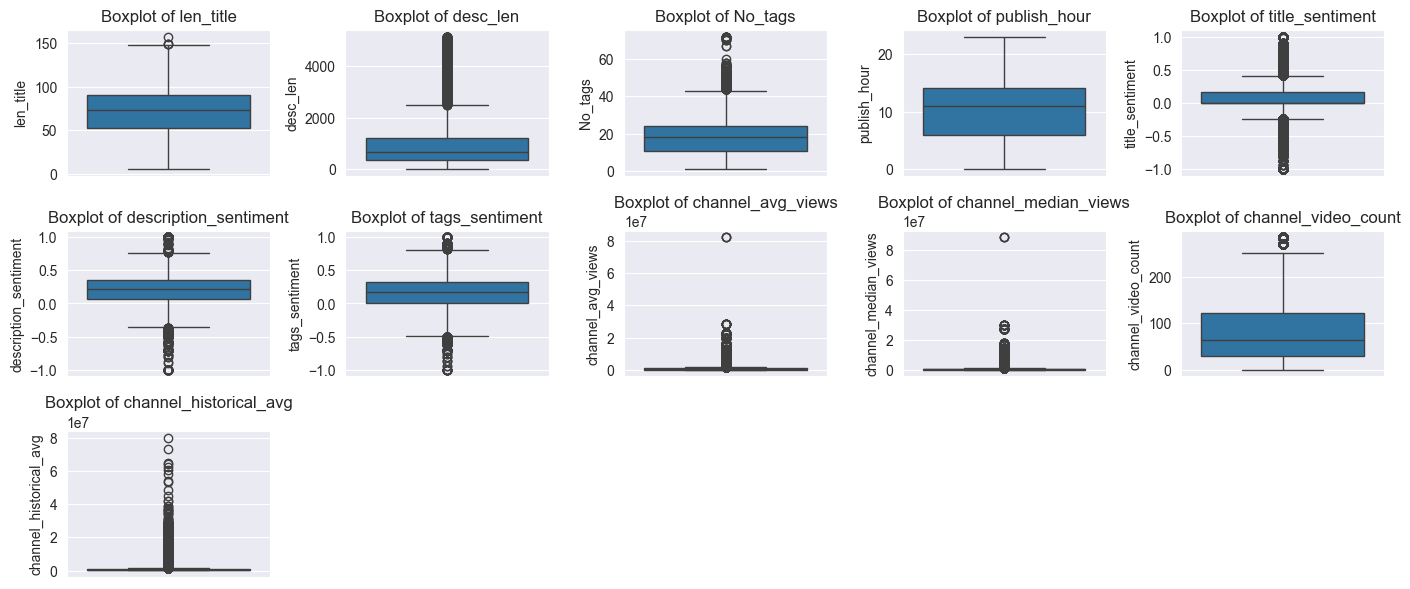

In [7]:
from utils import filter_outliers, plot_dynamic_boxplots_violinplots

# Combine train features and target for outlier detection
df_train = pd.concat([X_train_raw, y_train_raw], axis=1)

# Check outliers on TRAINING data only
excluded_cols = ['is_weekend_publish_day']
check_outliers_cols = [col for col in nums_cols if col not in excluded_cols]
outlier_summary = filter_outliers(df_train, columns=check_outliers_cols, threshold=1.5, detect_only=True)
display(outlier_summary)

# Visualize outliers in training data
plot_dynamic_boxplots_violinplots(df_train, check_outliers_cols, plot_type="boxplot", ncols=5, orientation="v", figsize=(14, 6))

In [8]:
# Remove outliers from TRAINING data and get IQR limits
# These limits will be applied to validation data to ensure consistent distributions
# (This prevents data leakage by using only training statistics)

# Step 1: Get IQR limits from training data
train_outlier_summary = filter_outliers(df_train, columns=check_outliers_cols, method='iqr', threshold=1.5, detect_only=True, verbose=False)

# Step 2: Remove outliers from training data
df_train_clean = filter_outliers(df_train, columns=check_outliers_cols, method='iqr', threshold=1.5, detect_only=False)
X_train_clean = df_train_clean.drop(columns=[target])
y_train_clean = df_train_clean[target]

# Step 3: Apply SAME IQR limits to validation data (using training-derived thresholds)
# This ensures validation set has the same distribution as training, preventing the mismatch issue
def filter_using_training_limits(data, columns, limits_df):
    """
    Filter outliers using pre-computed IQR limits from training data.
    This prevents data leakage while ensuring consistent distributions.
    """
    mask = pd.Series([True] * len(data), index=data.index)
    
    for _, row in limits_df.iterrows():
        col = row['Column Name']
        if col in columns and col in data.columns:
            lower = row['Lower Limit']
            upper = row['Upper Limit']
            col_mask = (data[col] >= lower) & (data[col] <= upper)
            mask = mask & col_mask
    
    return data[mask]

# Combine validation features and target for filtering
df_val = pd.concat([X_val_raw, y_val_raw], axis=1)
df_val_clean = filter_using_training_limits(df_val, check_outliers_cols, train_outlier_summary)

# Split back into X and y
X_val_clean = df_val_clean.drop(columns=[target])
y_val_clean = df_val_clean[target]

print(f"Training samples after outlier removal: {len(X_train_clean):,}")
print(f"Removed {len(X_train_raw) - len(X_train_clean):,} outlier samples from training set")
print(f"\nValidation samples after applying training limits: {len(X_val_clean):,}")
print(f"Removed {len(X_val_raw) - len(X_val_clean):,} outlier samples from validation set")
print(f"\nTest set: {len(X_test_raw):,} (unchanged - for final evaluation only)")

Training samples after outlier removal: 17,824
Removed 9,761 outlier samples from training set

Validation samples after applying training limits: 4,753
Removed 2,603 outlier samples from validation set

Test set: 1,839 (unchanged - for final evaluation only)


## Feature Encoding

In [9]:
info_df = check_data_information(X_train_raw, X_train_clean.select_dtypes(include='object').columns.tolist())
display(info_df)

,Feature,Data Type,Null Values,Null Percentage,Zero Values,Zero Percentage,Negative Values,Negative Percentage,Empty Strings,Numeric in Object,Duplicated Values,Unique Values,Cardinality Ratio,Unique Sample
0,category_name,str,0,0.0,0,0.0,0,0.0,0,0,8,14,0.0005,"People & Blogs, Entertainment, Comedy, Film & ..."
1,publish_day,str,0,0.0,0,0.0,0,0.0,0,0,8,7,0.0003,"Sunday, Wednesday, Thursday, Friday, Saturday"
2,publish_month,str,0,0.0,0,0.0,0,0.0,0,0,8,8,0.0003,"June, March, January, December, February"
3,publish_hour_category,str,0,0.0,0,0.0,0,0.0,0,0,8,4,0.0001,"Afternoon, Morning, Night, Evening"


- Ordinal Encoding: 
    - `title_sentiment_label`
    - `description_sentiment_label`
    - `tags_sentiment_label`

- One-hot Encoding: 
    - `category_name`
    - `publish_day`, `publish_hour_category`, `publish_month`

In [10]:
from utils import feature_encoding

# Make copies for encoding
X_train_encoded = X_train_clean.copy()
X_val_encoded = X_val_clean.copy()
X_test_encoded = X_test_raw.copy()

# Define categorical columns for feature encoding
# ordinal_cols = ['title_sentiment_label', 'description_sentiment_label', 'tags_sentiment_label']
# ordinal_categories = {
#     "title_sentiment_label": ['Negative', 'Neutral', 'Positive'],
#     "description_sentiment_label": ['Negative', 'Neutral', 'Positive'],
#     "tags_sentiment_label": ['Negative', 'Neutral', 'Positive']
# }

ohe_cols = ['category_name', 'publish_day', 'publish_hour_category', 'publish_month']

# Fit on training data
X_train_encoded, encoders = feature_encoding(
    X_train_encoded,
    # ordinal_columns=ordinal_cols,
    # ordinal_categories=ordinal_categories,
    nominal_columns=ohe_cols,
    handle_unknown='ignore'
)

# Transform validation data (reuses fitted encoders)
X_val_encoded, _ = feature_encoding(
    X_val_encoded,
    # ordinal_columns=ordinal_cols,
    # ordinal_categories=ordinal_categories,
    nominal_columns=ohe_cols,
    handle_unknown='ignore'
)

# Transform test data (reuses fitted encoders)
X_test_encoded, _ = feature_encoding(
    X_test_encoded,
    # ordinal_columns=ordinal_cols,
    # ordinal_categories=ordinal_categories,
    nominal_columns=ohe_cols,
    handle_unknown='ignore'
)

print(f"Encoded features shape: {X_train_encoded.shape}")
print(f"\nFeature columns after encoding:")
print(X_train_encoded.columns.tolist())
print("Re-check the final encoded dataframe:")
display(X_train_encoded.head(3))

Encoded features shape: (17824, 41)

Feature columns after encoding:
['category_name_Comedy', 'category_name_Education', 'category_name_Entertainment', 'category_name_Film & Animation', 'category_name_Gaming', 'category_name_Howto & Style', 'category_name_Music', 'category_name_News & Politics', 'category_name_Nonprofits & Activism', 'category_name_People & Blogs', 'category_name_Science & Technology', 'category_name_Sports', 'category_name_Unknown', 'publish_day_Monday', 'publish_day_Saturday', 'publish_day_Sunday', 'publish_day_Thursday', 'publish_day_Tuesday', 'publish_day_Wednesday', 'publish_hour_category_Evening', 'publish_hour_category_Morning', 'publish_hour_category_Night', 'publish_month_December', 'publish_month_February', 'publish_month_January', 'publish_month_June', 'publish_month_March', 'publish_month_May', 'publish_month_November', 'len_title', 'desc_len', 'No_tags', 'is_weekend_publish_day', 'publish_hour', 'title_sentiment', 'description_sentiment', 'tags_sentiment',

,category_name_Comedy,category_name_Education,category_name_Entertainment,category_name_Film & Animation,category_name_Gaming,category_name_Howto & Style,category_name_Music,category_name_News & Politics,category_name_Nonprofits & Activism,category_name_People & Blogs,category_name_Science & Technology,category_name_Sports,category_name_Unknown,publish_day_Monday,publish_day_Saturday,publish_day_Sunday,publish_day_Thursday,publish_day_Tuesday,publish_day_Wednesday,publish_hour_category_Evening,publish_hour_category_Morning,publish_hour_category_Night,publish_month_December,publish_month_February,publish_month_January,publish_month_June,publish_month_March,publish_month_May,publish_month_November,len_title,desc_len,No_tags,is_weekend_publish_day,publish_hour,title_sentiment,description_sentiment,tags_sentiment,channel_avg_views,channel_median_views,channel_video_count,channel_historical_avg
20369,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,38,552,15,0,11,0.00,-0.300000,0.250,3.283864e+05,300749.0,99,275195.684211
10829,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,48,111,11,0,10,0.00,0.375000,0.375,1.532714e+05,123946.0,24,75325.500000
7652,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,43,1499,32,0,11,0.25,0.392857,0.100,1.019760e+06,955981.5,170,621187.611111


## Feature Selection

In [11]:
from utils import calculate_correlation_tabular

# Combine train data for correlation analysis
df_train_encoded = pd.concat([X_train_encoded, y_train_clean.reset_index(drop=True)], axis=1)

# Calculate correlation on TRAINING data only
feature_feature_df, feature_target_df = calculate_correlation_tabular(
    df_train_encoded, 
    target_col='views', 
    method='spearman', 
    corr_type='both'
)

Correlation Between Features:


,A,B,Corr Value,Corr Type
0,channel_median_views,channel_avg_views,0.944108,Positive
1,channel_avg_views,channel_historical_avg,0.845316,Positive
2,channel_historical_avg,channel_median_views,0.837993,Positive
3,is_weekend_publish_day,publish_day_Saturday,0.700254,Positive
4,publish_hour_category_Night,publish_hour,0.689324,Negative
5,publish_day_Sunday,is_weekend_publish_day,0.596865,Positive
6,publish_hour,publish_hour_category_Evening,0.453351,Positive
7,category_name_Entertainment,category_name_News & Politics,0.427739,Negative
8,publish_hour_category_Morning,publish_hour_category_Night,0.367188,Negative
9,publish_hour_category_Morning,publish_hour,0.324159,Negative



Correlation of Features to Target:


,Feature,Corr Value,Corr Type
0,publish_day_Tuesday,0.029187,Negative
1,category_name_Education,0.021100,Positive
2,publish_month_January,0.020876,Negative
3,No_tags,0.020791,Negative
4,publish_month_December,0.019296,Positive
5,tags_sentiment,0.018188,Negative
6,channel_avg_views,0.015467,Negative
7,category_name_Entertainment,0.015293,Negative
8,len_title,0.014169,Positive
9,category_name_Science & Technology,0.013771,Negative


In [12]:
from utils import calculate_feature_importance

# Calculate amova on TRAINING data only
feature_importance_f = calculate_feature_importance(
    X=X_train_encoded, 
    y=y_train_clean.reset_index(drop=True), 
    task='regression', 
    method='f_regression', 
    k='all'
)

print("Feature importance (F-regression, top 15):")
display(feature_importance_f.iloc[:15].reset_index(drop=True))

Feature importance (F-regression, top 15):


,Feature,Score,P_Values
0,channel_avg_views,8789.183545,0.000000e+00
1,channel_historical_avg,7083.347739,0.000000e+00
2,channel_median_views,6242.081332,0.000000e+00
3,category_name_Education,191.922644,2.031379e-43
4,desc_len,156.862617,7.764171e-36
5,category_name_Music,156.701840,8.412417e-36
6,category_name_Unknown,148.167397,5.947549e-34
7,category_name_Comedy,140.206305,3.169049e-32
8,No_tags,116.497543,4.484781e-27
9,category_name_Film & Animation,106.577407,6.476603e-25


In [13]:
# Calculate mutual information on TRAINING data only
feature_importance_mi = calculate_feature_importance(
    X=X_train_encoded, 
    y=y_train_clean.reset_index(drop=True), 
    task='regression', 
    method='mutual_info', 
    k='all'
)

print("Feature importance (Mutual Info, top 15):")
display(feature_importance_mi.iloc[:15].reset_index(drop=True))

Feature importance (Mutual Info, top 15):


,Feature,Score,P_Values
0,channel_median_views,0.550065,None
1,channel_avg_views,0.546694,None
2,channel_historical_avg,0.395125,None
3,channel_video_count,0.291132,None
4,desc_len,0.162341,None
5,description_sentiment,0.144872,None
6,tags_sentiment,0.133606,None
7,No_tags,0.113182,None
8,len_title,0.112296,None
9,publish_hour,0.099378,None


In [14]:
# Select features based on training data analysis
base_cols = ["channel_median_views", "channel_avg_views", "channel_historical_avg", "channel_video_count", 
    "desc_len", "title_sentiment", "description_sentiment", "tags_sentiment", "No_tags", "len_title", "publish_hour"]
category_name_cols = [col for col in X_train_encoded.columns if col.startswith("category_name")]
selected_cols = base_cols + category_name_cols

# Apply feature selection to all sets
X_train_selected = X_train_encoded[selected_cols]
X_val_selected = X_val_encoded[selected_cols]
X_test_selected = X_test_encoded[selected_cols]

print(f"Selected {len(selected_cols)} features for modeling")
print(f"\nTraining set: {X_train_selected.shape}")
print(f"Validation set: {X_val_selected.shape}")
print(f"Test set: {X_test_selected.shape}")

Selected 24 features for modeling

Training set: (17824, 24)
Validation set: (4753, 24)
Test set: (1839, 24)


## Feature Scaling

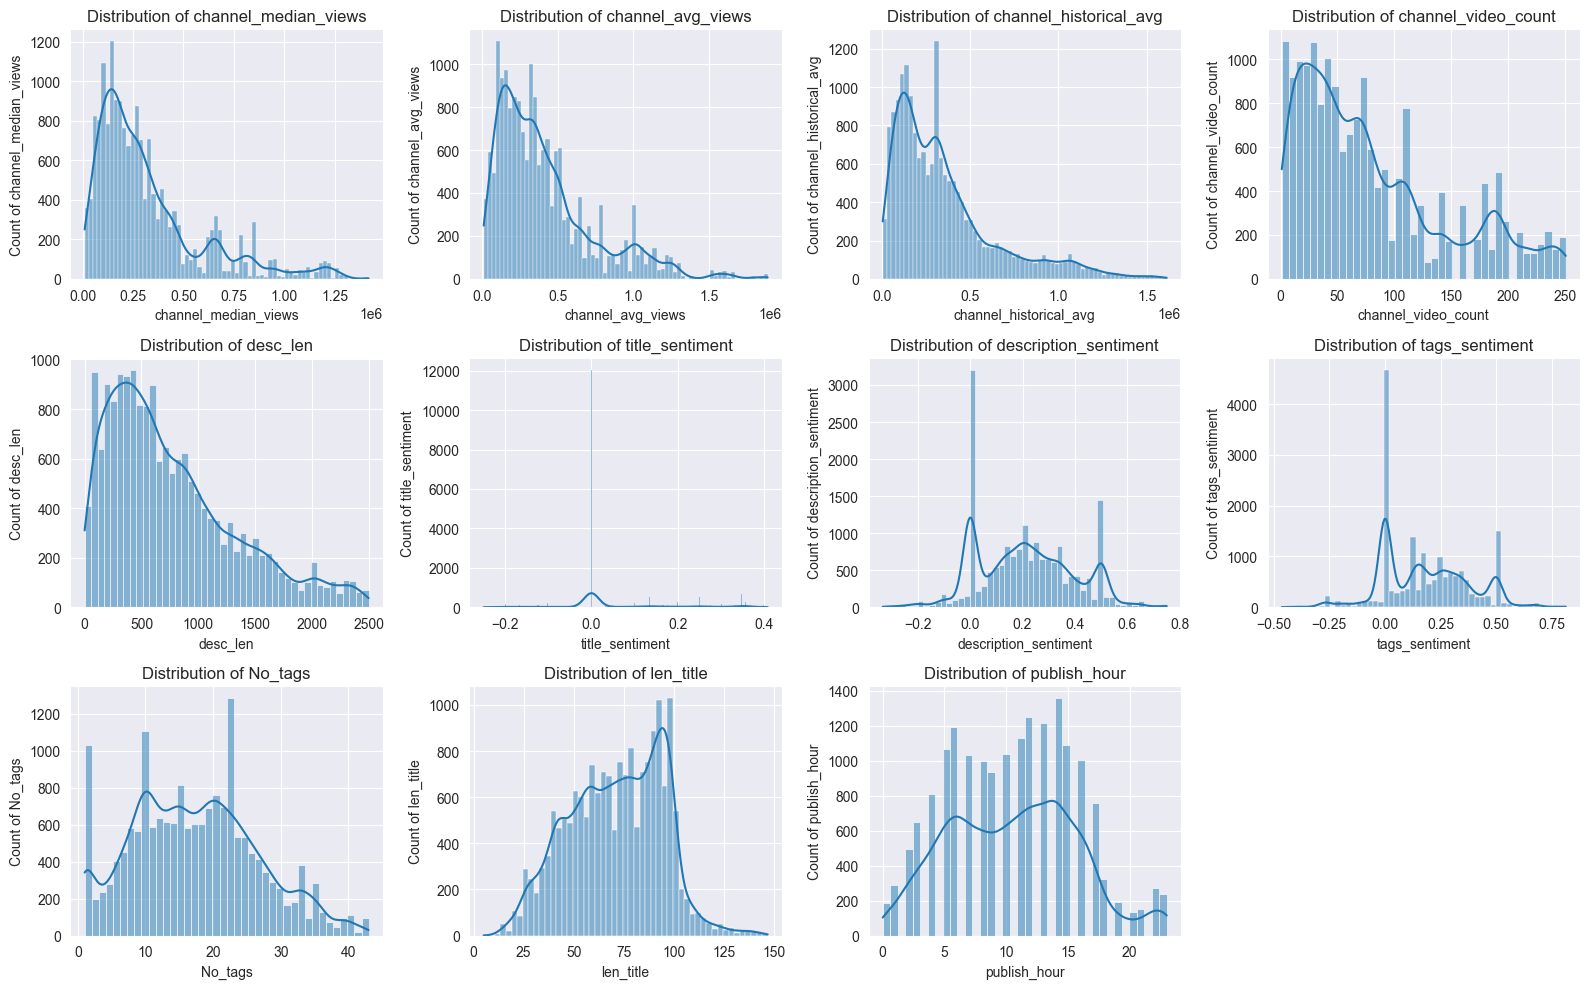

In [15]:
# Check distribution before scaling
from utils import plot_dynamic_hisplots_kdeplots
plot_dynamic_hisplots_kdeplots(df=X_train_selected, col_series=base_cols, ncols=4, figsize=(16, 10))

In [16]:
from utils import feature_scaling

# Define scaling configuration
scaling_config = {
    "robust": {
        # Right-skewed distributions with heavy tails/outliers — RobustScaler uses IQR, outlier-resistant
        "columns": [
            "channel_median_views",     # Heavy right-skew, long tail into millions
            "channel_avg_views",        # Heavy right-skew, long tail into millions
            "channel_historical_avg",   # Heavy right-skew, long tail into millions
            "channel_video_count",      # Right-skewed, spike at low counts, long right tail
            "desc_len",                 # Exponential decay shape, spike near 0, long right tail
            "No_tags",                  # Irregular multimodal with visible outlier spikes
        ]
    },
    "minmax": {
        # Bounded / known fixed ranges — safe to scale to [0, 1]
        "columns": [
            "title_sentiment",          # Bounded sentiment score, narrow range [-0.2, 0.4]
            "description_sentiment",    # Bounded sentiment score, multimodal [-0.25, 0.8]
            "tags_sentiment",           # Bounded sentiment score, multimodal [-0.5, 0.75]
            "len_title",                # Bounded [0, 150], roughly bell-shaped, no heavy tail
            "publish_hour",             # Fixed known range [0, 23], cyclical-ish
        ]
    }
}

# FIT scalers on TRAINING data only
X_train_scaled, scalers = feature_scaling(
    data=X_train_selected.copy(),
    scaling_config=scaling_config
)

# TRANSFORM validation data using fitted scalers
X_val_scaled, _ = feature_scaling(
    data=X_val_selected.copy(),
    scaling_config=scaling_config,
    scaler=scalers
)

# TRANSFORM test data using fitted scalers
X_test_scaled, _ = feature_scaling(
    data=X_test_selected.copy(),
    scaling_config=scaling_config,
    scaler=scalers
)

print(f"Training set:   {X_train_scaled.shape[0]} samples ({X_train_scaled.shape[0]/total_samples*100:.1f}%)")
print(f"Validation set: {X_val_scaled.shape[0]} samples ({X_val_scaled.shape[0]/total_samples*100:.1f}%)")
print(f"Test set:       {X_test_scaled.shape[0]} samples ({X_test_scaled.shape[0]/total_samples*100:.1f}%)")

Training set:   17824 samples (48.5%)
Validation set: 4753 samples (12.9%)
Test set:       1839 samples (5.0%)


In [17]:
# Save PREPROCESSED test data (for model evaluation)
# This is what the model sees during inference
df_test_preprocessed = pd.concat([X_test_scaled.reset_index(drop=True), y_test_raw.reset_index(drop=True)], axis=1)
df_test_preprocessed.to_csv('data/test_data_5%_preprocessed.csv', index=False)
print(f"Preprocessed test data saved to: data/test_data_5%_preprocessed.csv")
print(f"Shape: {df_test_preprocessed.shape}")

Preprocessed test data saved to: data/test_data_5%_preprocessed.csv
Shape: (1839, 25)


# **STAGE 3 : MODELLING AND EVALUATION**

## Model Training

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Define baseline models
models = {
    'Linear Regression': LinearRegression(),
    'KNN': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}

# Train all baseline models
baseline_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train_clean)
    baseline_models[name] = model

print("\nAll models trained successfully!")

Training Linear Regression...
Training KNN...
Training Decision Tree...
Training Random Forest...
Training XGBoost...

All models trained successfully!


## Model Evaluation


Evaluating: Linear Regression
Performance Metrics for LinearRegression:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  241575.4358 ± 5282.0778
  Train: 240988.9296 ± 1812.8923

MSE:
  Test:  218713787001.6352 ± 28740584544.1457
  Train: 217422275031.1344 ± 7186225642.1516

RMSE:
  Test:  466667.4878 ± 30581.7402
  Train: 466221.5234 ± 7730.8581

MAPE:
  Test:  120.38% ± 3.41%
  Train: 120.16% ± 0.98%

R2:
  Test:  0.3492 ± 0.0241
  Train: 0.3518 ± 0.0060

Single Run Metrics:

MAE:
  Test:  244604.3058
  Train: 240940.7450

MSE:
  Test:  205533865276.4714
  Train: 217551152784.7505

RMSE:
  Test:  453358.4291
  Train: 466423.7910

MAPE:
  Test:  121.93%
  Train: 120.03%

R2:
  Test:  0.3702
  Train: 0.3513


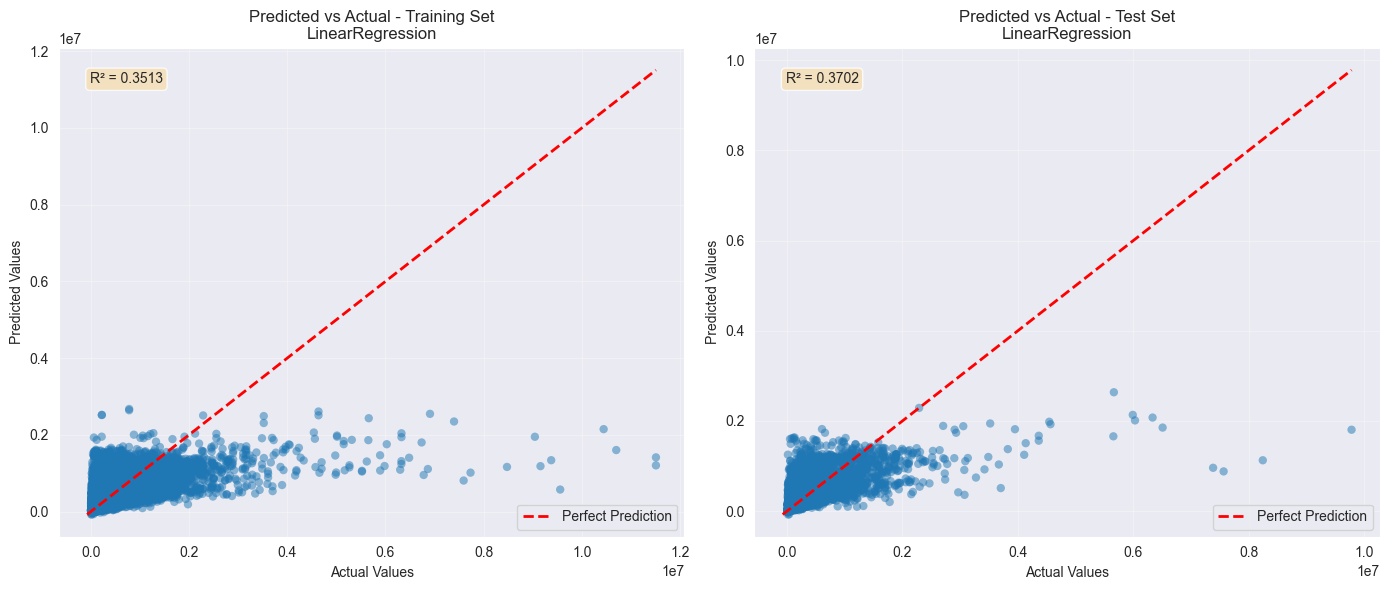


Evaluating: KNN
Performance Metrics for KNeighborsRegressor:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  209594.0471 ± 5475.8255
  Train: 164076.3157 ± 1126.2965

MSE:
  Test:  174685011082.7594 ± 29246463678.6400
  Train: 111572694660.4760 ± 6374987429.2694

RMSE:
  Test:  416530.1416 ± 34462.3303
  Train: 333885.6558 ± 9646.9445

MAPE:
  Test:  102.45% ± 3.09%
  Train: 80.04% ± 0.62%

R2:
  Test:  0.4804 ± 0.0543
  Train: 0.6674 ± 0.0140

Single Run Metrics:

MAE:
  Test:  198904.4238
  Train: 155753.7393

MSE:
  Test:  143016763586.7404
  Train: 104078725711.0215

RMSE:
  Test:  378175.5724
  Train: 322612.3459

MAPE:
  Test:  97.15%
  Train: 76.35%

R2:
  Test:  0.5618
  Train: 0.6897


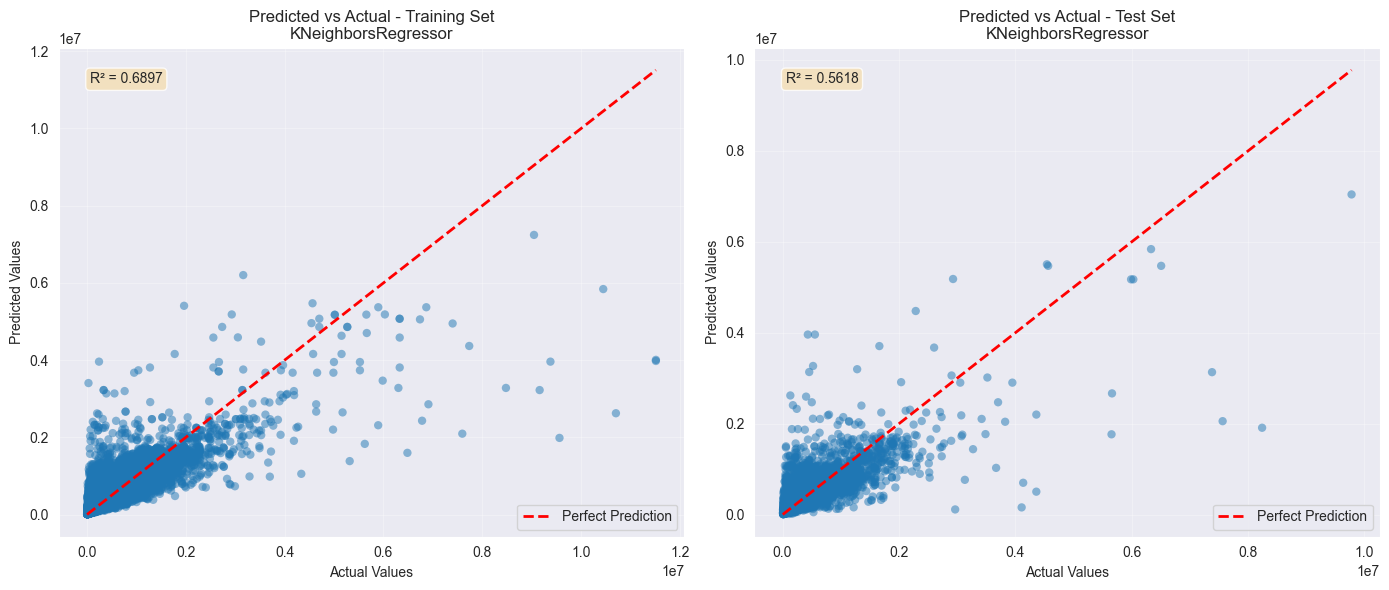


Evaluating: Decision Tree
Performance Metrics for DecisionTreeRegressor:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  218947.6381 ± 5892.7578
  Train: 22.4010 ± 7.5183

MSE:
  Test:  238037310837.5357 ± 31320655704.5752
  Train: 1432477.4852 ± 546423.1262

RMSE:
  Test:  486862.5428 ± 31657.1514
  Train: 1172.1666 ± 241.8741

MAPE:
  Test:  96.74% ± 4.08%
  Train: 0.01% ± 0.00%

R2:
  Test:  0.2874 ± 0.0819
  Train: 1.0000 ± 0.0000

Single Run Metrics:

MAE:
  Test:  209613.4845
  Train: 27.8945

MSE:
  Test:  218350059581.5195
  Train: 1802912.0490

RMSE:
  Test:  467279.4235
  Train: 1342.7256

MAPE:
  Test:  94.34%
  Train: 0.01%

R2:
  Test:  0.3309
  Train: 1.0000


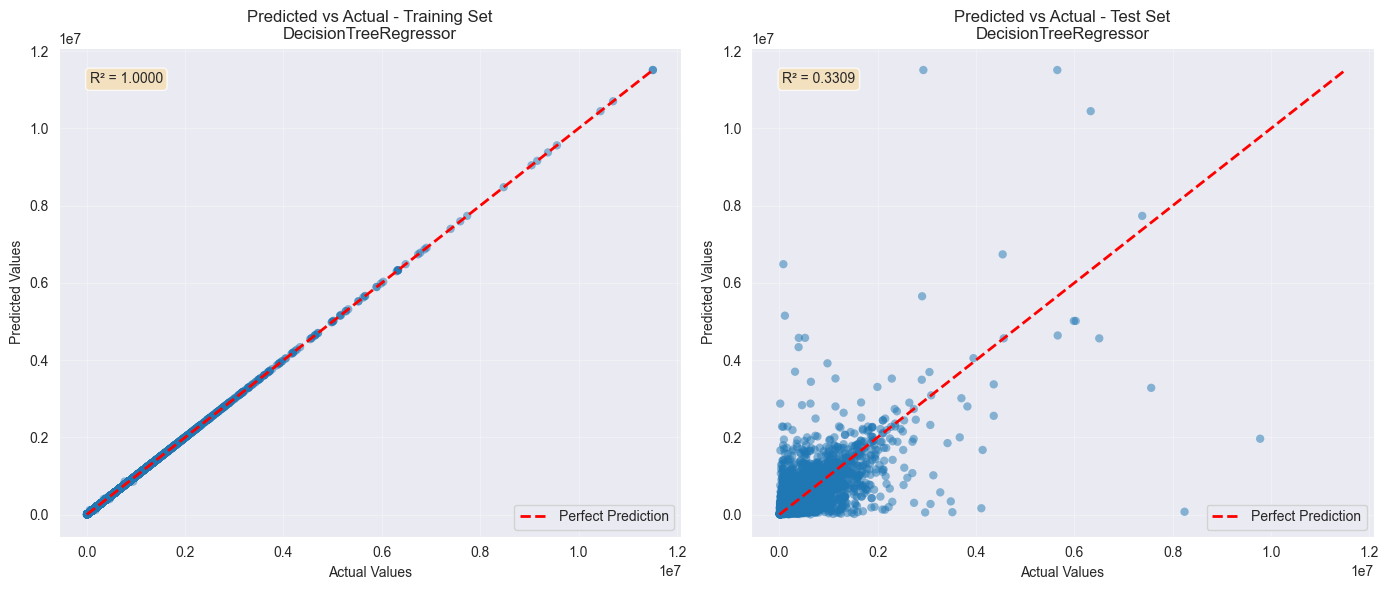


Evaluating: Random Forest
Performance Metrics for RandomForestRegressor:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  183229.8178 ± 4158.7535
  Train: 68142.1699 ± 517.4046

MSE:
  Test:  142650769108.0092 ± 29439798727.6615
  Train: 20264349999.9159 ± 1360956024.1736

RMSE:
  Test:  375767.7756 ± 38070.3022
  Train: 142272.3799 ± 4787.4737

MAPE:
  Test:  89.57% ± 2.72%
  Train: 32.96% ± 0.29%

R2:
  Test:  0.5764 ± 0.0615
  Train: 0.9396 ± 0.0032

Single Run Metrics:

MAE:
  Test:  174308.5164
  Train: 65671.2049

MSE:
  Test:  114318969123.3134
  Train: 18723723267.7902

RMSE:
  Test:  338110.8829
  Train: 136834.6567

MAPE:
  Test:  84.76%
  Train: 31.64%

R2:
  Test:  0.6497
  Train: 0.9442


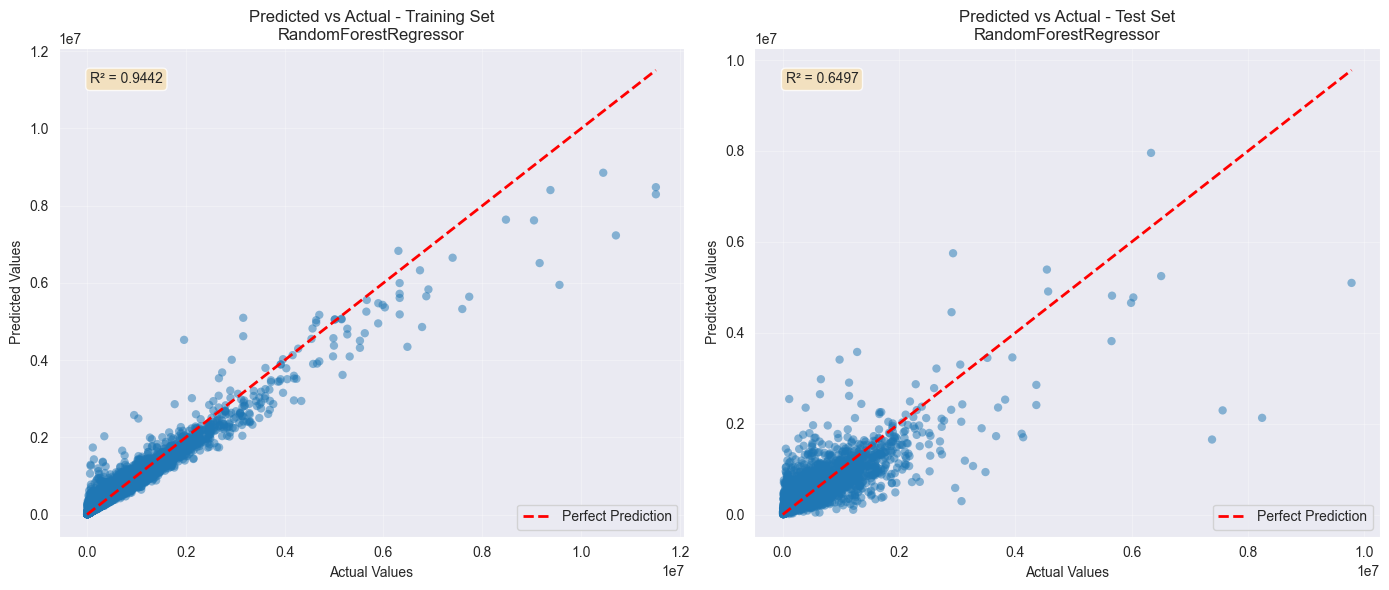


Evaluating: XGBoost
Performance Metrics for XGBRegressor:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  193890.0448 ± 4336.8210
  Train: 125306.9094 ± 1365.1923

MSE:
  Test:  146592137216.0000 ± 29250508901.9094
  Train: 36939051281.0667 ± 1143431994.7194

RMSE:
  Test:  381066.2589 ± 37157.0119
  Train: 192172.1137 ± 2988.3099

MAPE:
  Test:  97.36% ± 2.45%
  Train: 68.40% ± 0.90%

R2:
  Test:  0.5650 ± 0.0560
  Train: 0.8898 ± 0.0031

Single Run Metrics:

MAE:
  Test:  190461.0625
  Train: 129939.4219

MSE:
  Test:  130930974720.0000
  Train: 40022536192.0000

RMSE:
  Test:  361843.8438
  Train: 200056.3281

MAPE:
  Test:  94.45%
  Train: 69.94%

R2:
  Test:  0.5988
  Train: 0.8807


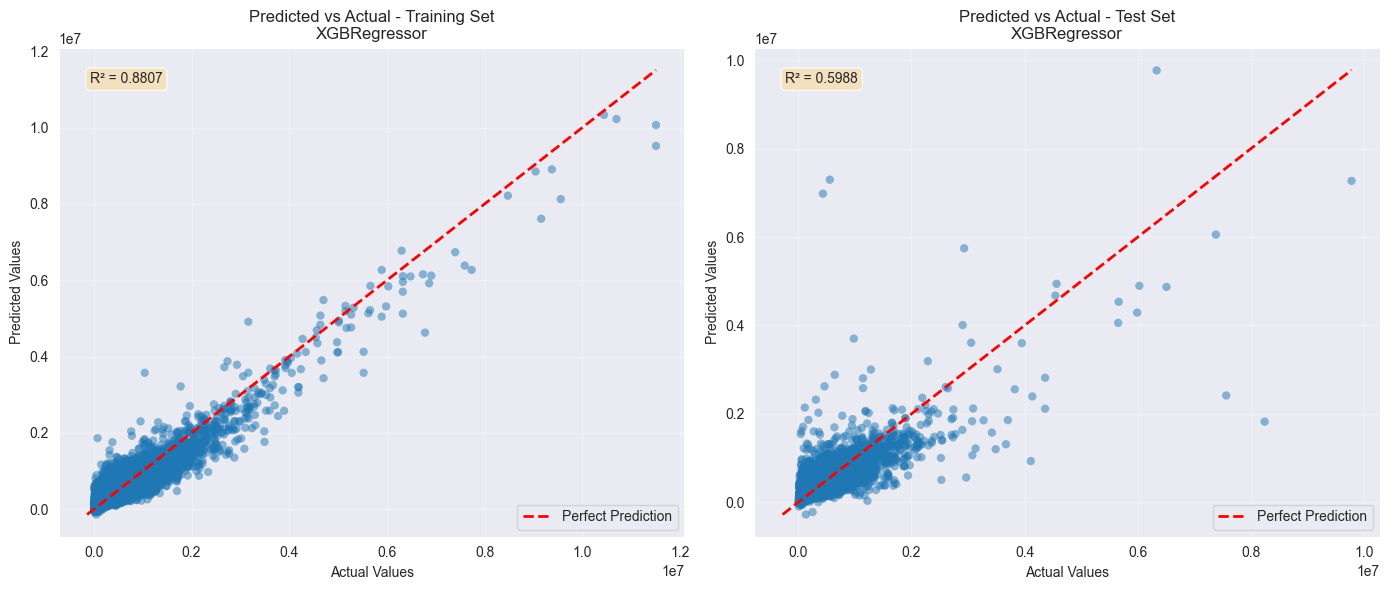

In [21]:
# Import regression evaluation and tuning utilities
from utils import eval_regression

# Evaluate each baseline model on validation set
baseline_metrics = {}

for name, model in baseline_models.items():
    print(f"\n{'='*60}")
    print(f"Evaluating: {name}")
    print('='*60)
    
    metrics = eval_regression(
        model=model,
        X_train=X_train_scaled,
        y_train=y_train_clean,
        X_test=X_val_scaled,
        y_test=y_val_clean,
        plot_predicted_vs_actual=True,
        plot_residuals=False,
        plot_residuals_dist=False
    )
    
    baseline_metrics[name] = metrics

In [22]:
# Compare all baseline models
from utils import compare_cv_metrics_regression

comparison_df = compare_cv_metrics_regression(baseline_metrics)
print("\n=== BASELINE MODEL COMPARISON (Cross-Validation) ===\n")
display(comparison_df)


=== BASELINE MODEL COMPARISON (Cross-Validation) ===



,Model,MAE,MSE,RMSE,MAPE,R2
0,Linear Regression,241575.4358 ± 5282.0778,218713787001.6352 ± 28740584544.1457,466667.4878 ± 30581.7402,120.38% ± 3.41%,0.3492 ± 0.0241
1,KNN,209594.0471 ± 5475.8255,174685011082.7594 ± 29246463678.6400,416530.1416 ± 34462.3303,102.45% ± 3.09%,0.4804 ± 0.0543
2,Decision Tree,218947.6381 ± 5892.7578,238037310837.5357 ± 31320655704.5752,486862.5428 ± 31657.1514,96.74% ± 4.08%,0.2874 ± 0.0819
3,Random Forest,183229.8178 ± 4158.7535,142650769108.0092 ± 29439798727.6615,375767.7756 ± 38070.3022,89.57% ± 2.72%,0.5764 ± 0.0615
4,XGBoost,193890.0448 ± 4336.8210,146592137216.0000 ± 29250508901.9094,381066.2589 ± 37157.0119,97.36% ± 2.45%,0.5650 ± 0.0560


In [23]:
# Find the best model for each metric
metrics_list = ['mae', 'rmse', 'mape', 'r2']
best_models = {}

for metric in metrics_list:
    best_score = 0
    best_name = None
    
    for name, metrics in baseline_metrics.items():
        if 'cv' in metrics and metric in metrics['cv']:
            score = metrics['cv'][metric]['test_mean']
            if score > best_score:
                best_score = score
                best_name = name
    
    best_models[metric] = {'model_name': best_name, 'score': best_score}

# Calculate average score across all metrics for each model (best overall)
model_avg_scores = {}
for name, metrics in baseline_metrics.items():
    if 'cv' in metrics:
        scores = []
        for metric in metrics_list:
            if metric in metrics['cv']:
                scores.append(metrics['cv'][metric]['test_mean'])
        if scores:
            model_avg_scores[name] = sum(scores) / len(scores)

# Find best overall model
best_overall_name = max(model_avg_scores, key=model_avg_scores.get)
best_overall_avg = model_avg_scores[best_overall_name]

print("=== Best Model for Each Metric ===\n")
for metric, info in best_models.items():
    print(f"★ {metric.upper():12s}: {info['model_name']} ({info['score']*100:.2f}%)")

print("\n=== Average Scores Across All Metrics ===\n")
for name, avg_score in sorted(model_avg_scores.items(), key=lambda x: x[1], reverse=True):
    marker = "★" if name == best_overall_name else " "
    print(f"{marker} {name:25s}: {avg_score*100:.2f}%")

print(f"\n→ Best Overall Model: {best_overall_name} (avg = {best_overall_avg*100:.2f}%)")

=== Best Model for Each Metric ===

★ MAE         : Linear Regression (24157543.58%)
★ RMSE        : Decision Tree (48686254.28%)
★ MAPE        : Linear Regression (120.38%)
★ R2          : Random Forest (57.64%)

=== Average Scores Across All Metrics ===

★ Linear Regression        : 17706111.92%
  Decision Tree            : 17645285.90%
  KNN                      : 15653142.34%
  XGBoost                  : 14373946.06%
  Random Forest            : 13974976.64%

→ Best Overall Model: Linear Regression (avg = 17706111.92%)


## Feature Importance

### 1. Random Forest Feature Importance (Gini-based)

**Method:** Measures average impurity reduction across all trees when splitting on each feature.

**Pros:** Fast, built-in, captures feature usage in tree structure

**Cons:** Biased toward high-cardinality features, doesn't account for feature interactions


FEATURE IMPORTANCE (GINI-BASED)

Top 15 Most Important Features:


,Feature,Importance
0,channel_avg_views,0.359775
1,channel_historical_avg,0.165564
2,desc_len,0.082523
3,channel_median_views,0.065959
4,len_title,0.056818
5,tags_sentiment,0.051188
6,publish_hour,0.049393
7,description_sentiment,0.045219
8,title_sentiment,0.037296
9,No_tags,0.035578


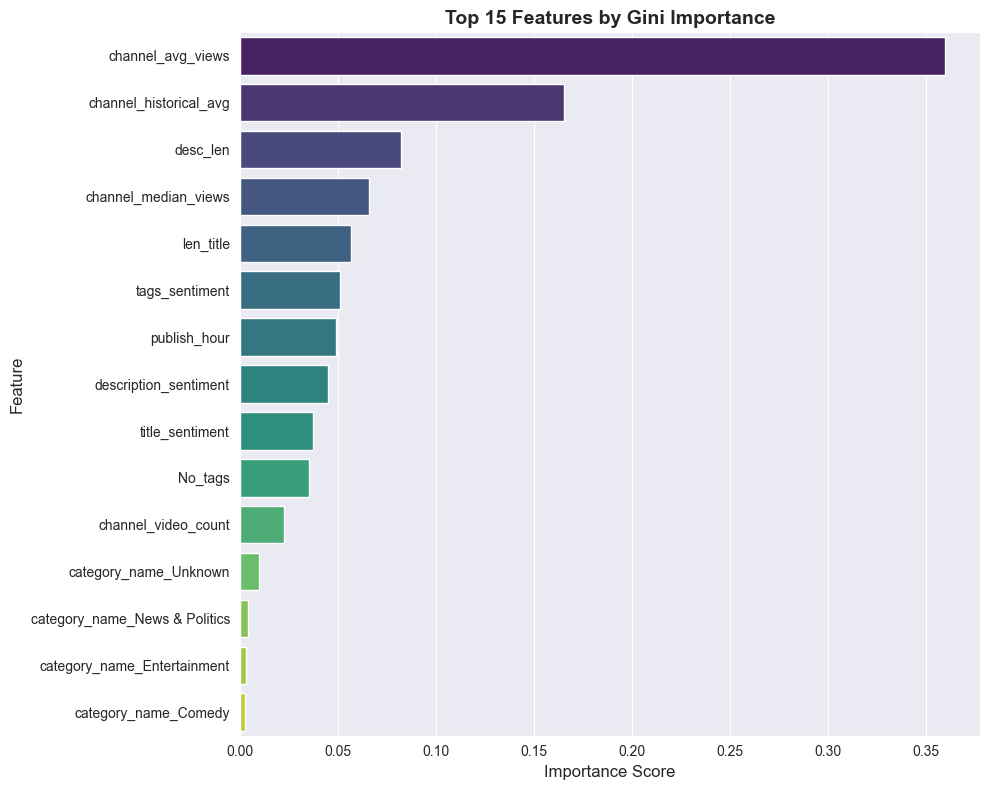


Total features: 24
Top 5 features contribute: 73.06% of total importance
Top 10 features contribute: 94.93% of total importance


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

best_model_name= "Random Forest"

# Extract feature importances from the trained model
feature_importance_gini = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': baseline_models[best_model_name].feature_importances_
}).sort_values('Importance', ascending=False)

# Display top features
print("\n" + "="*60)
print("FEATURE IMPORTANCE (GINI-BASED)")
print("="*60)
print("\nTop 15 Most Important Features:")
display(feature_importance_gini.head(15).reset_index(drop=True))

# Visualize
plt.figure(figsize=(10, 8))
top_n = 15
sns.barplot(
    data=feature_importance_gini.head(top_n),
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title(f'Top {top_n} Features by Gini Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nTotal features: {len(feature_importance_gini)}")
print(f"Top 5 features contribute: {feature_importance_gini.head(5)['Importance'].sum():.2%} of total importance")
print(f"Top 10 features contribute: {feature_importance_gini.head(10)['Importance'].sum():.2%} of total importance")

### 2. Permutation Importance

**Method:** Shuffles each feature and measures the resulting drop in model performance (R²).

**Pros:** More reliable than Gini, works with any model, reflects actual prediction impact

**Cons:** Slower (requires multiple predictions), can be affected by correlated features

**Note:** We compute on validation set to avoid overfitting to training data patterns.


Computing permutation importance (this may take a minute)...

PERMUTATION IMPORTANCE (R² DECREASE)

Top 15 Most Important Features:


,Feature,Importance_Mean,Importance_Std
0,channel_median_views,1.629444,0.076737
1,channel_avg_views,1.135058,0.034995
2,channel_historical_avg,0.220712,0.016805
3,desc_len,0.112018,0.024590
4,publish_hour,0.060281,0.004815
5,len_title,0.057394,0.006355
6,title_sentiment,0.055248,0.008092
7,tags_sentiment,0.042317,0.004801
8,description_sentiment,0.034919,0.004561
9,No_tags,0.026102,0.002855


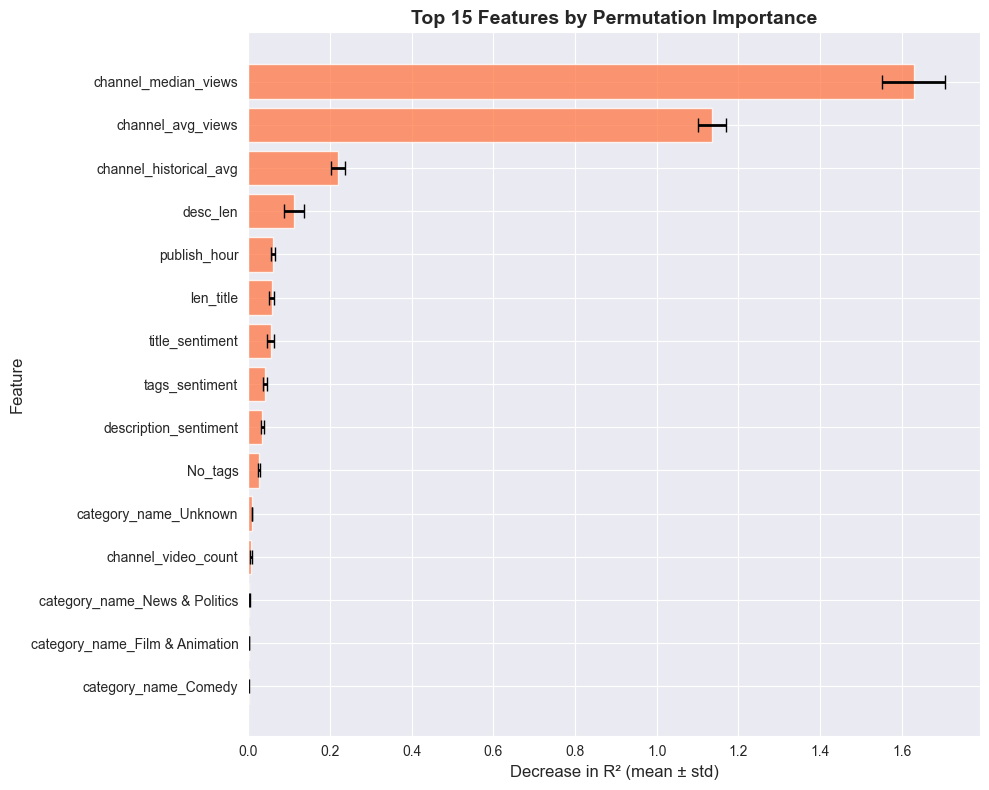


Interpretation: When we shuffle a feature's values, the model's R² drops by the importance score.
Higher drop = more important feature for predictions.


In [25]:
from sklearn.inspection import permutation_importance

print("\nComputing permutation importance (this may take a minute)...")

# Calculate permutation importance on VALIDATION set
perm_importance = permutation_importance(
    baseline_models[best_model_name],
    X_val_scaled,
    y_val_clean,
    n_repeats=10,
    random_state=42,
    scoring='r2',
    n_jobs=-1
)

# Create DataFrame with results
feature_importance_perm = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance_Mean': perm_importance.importances_mean,
    'Importance_Std': perm_importance.importances_std
}).sort_values('Importance_Mean', ascending=False)

# Display results
print("\n" + "="*60)
print("PERMUTATION IMPORTANCE (R² DECREASE)")
print("="*60)
print("\nTop 15 Most Important Features:")
display(feature_importance_perm.head(15).reset_index(drop=True))

# Visualize with error bars
plt.figure(figsize=(10, 8))
top_n = 15
top_features = feature_importance_perm.head(top_n)

plt.barh(
    range(len(top_features)),
    top_features['Importance_Mean'],
    xerr=top_features['Importance_Std'],
    color='coral',
    alpha=0.8,
    error_kw={'linewidth': 2, 'ecolor': 'black', 'capsize': 5}
)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Decrease in R² (mean ± std)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'Top {top_n} Features by Permutation Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nInterpretation: When we shuffle a feature's values, the model's R² drops by the importance score.")
print(f"Higher drop = more important feature for predictions.")

## Final Test Set Evaluation

FINAL TEST SET EVALUATION
Performance Metrics for RandomForestRegressor:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  183229.8178 ± 4158.7535
  Train: 68142.1699 ± 517.4046

MSE:
  Test:  142650769108.0092 ± 29439798727.6615
  Train: 20264349999.9159 ± 1360956024.1736

RMSE:
  Test:  375767.7756 ± 38070.3022
  Train: 142272.3799 ± 4787.4737

MAPE:
  Test:  89.57% ± 2.72%
  Train: 32.96% ± 0.29%

R2:
  Test:  0.5764 ± 0.0615
  Train: 0.9396 ± 0.0032

Single Run Metrics:

MAE:
  Test:  174308.5164
  Train: 65671.2049

MSE:
  Test:  114318969123.3134
  Train: 18723723267.7902

RMSE:
  Test:  338110.8829
  Train: 136834.6567

MAPE:
  Test:  84.76%
  Train: 31.64%

R2:
  Test:  0.6497
  Train: 0.9442


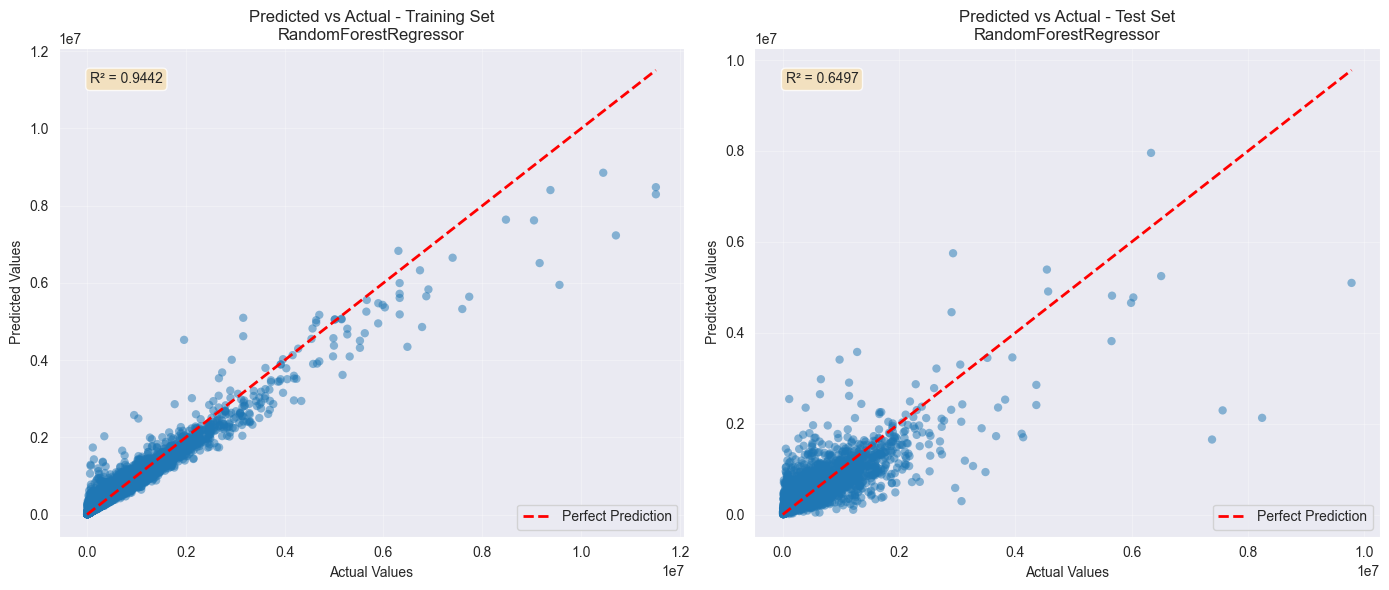


These are the final, unbiased performance metrics.


In [26]:
# Final evaluation on TEST set
print("=" * 60)
print("FINAL TEST SET EVALUATION")
print("=" * 60)

metrics_test = eval_regression(
    model=baseline_models[best_model_name],
    X_train=X_train_scaled,
    y_train=y_train_clean,
    X_test=X_val_scaled,
    y_test=y_val_clean,
    plot_predicted_vs_actual=True,
    plot_residuals=False,
    plot_residuals_dist=False
)

print("\n" + "=" * 60)
print("These are the final, unbiased performance metrics.")
print("=" * 60)

## Save Model and Artifacts

In [ ]:
# Re-checks artifacts to save
print(baseline_models[best_model_name])
print(scalers)
print(encoders)

RandomForestRegressor(random_state=42)
{'robust': RobustScaler(quantile_range=(5, 95)), 'minmax': MinMaxScaler()}
{'onehot_category_name': OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), 'onehot_publish_day': OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), 'onehot_publish_hour_category': OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), 'onehot_publish_month': OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)}


In [29]:
import joblib
import os

# Create models directory if it doesn't exist
models_dir = 'models'
if not os.path.exists(models_dir):
    os.makedirs(models_dir)
    print(f"Created '{models_dir}' directory.")

# Save the best model
joblib.dump(baseline_models[best_model_name], 'models/random_forest_model.joblib')
joblib.dump(scalers, 'models/scalers.joblib')
joblib.dump(encoders, 'models/encoders.joblib')

print("Model and preprocessing artifacts saved successfully!")
print(f"\nSaved files:")
print("- random_forest_model.joblib")
print("- scalers.joblib")
print("- encoders.joblib")

Created 'models' directory.
Model and preprocessing artifacts saved successfully!

Saved files:
- random_forest_model.joblib
- scalers.joblib
- encoders.joblib
